# Multimodal Simultaneous Bounded Attack (Variant B): Aggregation, Analysis & Figures

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

## Setup

In [1]:
import os, json, warnings, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

BASELINE_CSV       = 'evaluation/baseline_iou_all.csv'
VARIANT_A_CSV      = 'evaluation/variant_a/variant_a_samples.csv'   # exported by A's notebook
VARIANT_A_SOLS_CSV = 'evaluation/variant_a/variant_a_solutions.csv'
VARIANT_B_BASE_DIR = 'multimodal/variant_b'
OUTPUT_DIR         = 'evaluation/variant_b'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SCENE_TYPE_MAP = {
    'single/solo':  'Isolated',
    'single/multi': 'Clustered',
    'multi':        'Mixed',
}
SCENE_ORDER = ['Isolated', 'Clustered', 'Mixed']

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
})

## Constants & Mappings

In [2]:
IMAGE_ATTACKS = [
    'gaussian_noise',   # 1. Noise on clean pixels
    'defocus_blur',     # 2. Absorbs noise
    'motion_blur',      # 3. Compounds blur
    'fog_filter',       # 4. Global overlay
    'pixelate',         # 5. Locks in prior damage
    'jpeg_filter',      # 6. ALWAYS LAST -- simulates compression
]
TEXT_ATTACKS = [
    'homophone',        # 1. Dictionary lookup
    'synonym',          # 2. Dictionary lookup
    'ata_saliency',     # 3. Saliency-targeted typos
    'fragmentation',    # 4. Splits words
    'character_noise',  # 5. ALWAYS LAST -- character-level
]

N_IMG = len(IMAGE_ATTACKS)  # 6
N_TXT = len(TEXT_ATTACKS)   # 5
N_VAR = N_IMG + N_TXT      # 11

IMG_NICE = {
    'jpeg_filter': 'JPEG Compression', 'pixelate': 'Pixelation',
    'defocus_blur': 'Defocus Blur', 'motion_blur': 'Motion Blur',
    'gaussian_noise': 'Gaussian Noise', 'fog_filter': 'Fog Overlay',
}
TXT_NICE = {
    'homophone': 'Homophone', 'synonym': 'Synonym',
    'fragmentation': 'Fragmentation', 'character_noise': 'Character Noise',
    'ata_saliency': 'Lexical Saliency',
}

IMG_CATEGORY_MAP = {
    'jpeg_filter': 'Digital', 'pixelate': 'Digital',
    'defocus_blur': 'Blur', 'motion_blur': 'Blur',
    'gaussian_noise': 'Noise', 'fog_filter': 'Weather',
}
TXT_CATEGORY_MAP = {
    'homophone': 'Semantic', 'synonym': 'Semantic',
    'fragmentation': 'Orthographic', 'character_noise': 'Orthographic',
    'ata_saliency': 'Orthographic',
}

SCENE_COLORS = {'Isolated': '#2196F3', 'Clustered': '#FF9800', 'Mixed': '#E91E63'}

POP_SIZE = 30
NUM_GENERATIONS = 15
BATCH_SIZE = 15
BUDGET_MAX = 1.0
EARLY_STOP_IOU_MAX = 0.35
EARLY_STOP_IMG_DIST_MAX = 0.10
EARLY_STOP_TXT_SIM_MIN = 0.70


print(f'Image attacks: {N_IMG}, Text attacks: {N_TXT}')
print(f'Total decision variables: {N_VAR}')
print(f'Budget ceiling per modality: B = {BUDGET_MAX}')

Image attacks: 6, Text attacks: 5
Total decision variables: 11
Budget ceiling per modality: B = 1.0


## Load Variant B Results

In [3]:
def get_scene_type(category_str):
    """Map folder category to scene type label."""
    mapping = {
        'single/solo':  'Isolated',
        'single_solo':  'Isolated',
        'single/multi': 'Clustered',
        'single_multi': 'Clustered',
        'multi':        'Mixed',
    }
    cat = category_str.replace('\\', '/').strip('/')
    return mapping.get(cat, 'Unknown')


# Walk the output tree
sample_records = []   # one row per sample
solution_records = [] # one row per Pareto-front solution
errors = []

for rel_dir, scene_label in SCENE_TYPE_MAP.items():
    group_dir = os.path.join(VARIANT_B_BASE_DIR, rel_dir)
    if not os.path.isdir(group_dir):
        errors.append(f'MISSING DIR: {group_dir}')
        continue

    folder_ids = sorted(
        [d for d in os.listdir(group_dir) if os.path.isdir(os.path.join(group_dir, d))],
        key=lambda x: int(x)
    )

    for fid in folder_ids:
        pf_path = os.path.join(group_dir, fid, 'pareto_front.json')
        if not os.path.isfile(pf_path):
            errors.append(f'MISSING: {pf_path}')
            continue

        with open(pf_path) as f:
            pf = json.load(f)

        # --- Sample-level record ---
        sample_rec = {
            'scene_type':        scene_label,
            'sample_id':         int(fid),
            'folder_path':       pf['data_source']['folder_path'],
            'filename':          pf['data_source']['filename'],
            'baseline_iou':      pf['baseline_iou'],
            'swad_star':         pf['swad_star'],
            'swad_star_index':   pf['swad_star_index'],
            'early_stopped':     pf['early_stopped'],
            'early_stop_gen':    pf.get('early_stop_generation'),
            'total_evaluations': pf['total_evaluations'],
            'skipped_evals':     pf['skipped_evaluations'],
            'n_solutions':       pf['n_solutions'],
            'n_gt_objects':      len(pf['ground_truth_bboxes']),
            'budget_max':        pf.get('budget_max', BUDGET_MAX),
        }

        # --- Extract SWAD*-optimal solution details ---
        swad_idx = pf['swad_star_index']
        swad_sol = pf['solutions'][swad_idx]
        genome = swad_sol['genome']

        # Per-corruption severity scales (SWAD*-optimal)
        for atk in IMAGE_ATTACKS:
            sample_rec[f'swad_img_{atk}'] = genome['image_corruptions'].get(atk, 0.0)
        for atk in TEXT_ATTACKS:
            sample_rec[f'swad_txt_{atk}'] = genome['text_corruptions'].get(atk, 0.0)

        # Budget utilization
        sample_rec['swad_img_budget_used'] = genome.get('img_budget_used', 
            sum(genome['image_corruptions'].values()))
        sample_rec['swad_txt_budget_used'] = genome.get('txt_budget_used',
            sum(genome['text_corruptions'].values()))

        # Objectives
        sample_rec['swad_iou_m']       = swad_sol['objectives']['iou']
        sample_rec['swad_img_dist']    = swad_sol['objectives']['img_dist']
        sample_rec['swad_txt_sim']     = swad_sol['objectives']['txt_sim']
        sample_rec['swad_txt_dist']    = swad_sol['objectives']['txt_dist']
        sample_rec['swad_delta_m']     = swad_sol['swad_metrics']['delta_m_plus']
        sample_rec['swad_phi']         = swad_sol['swad_metrics']['phi']
        sample_rec['swad_token_count'] = swad_sol['vlm_output']['token_count']
        sample_rec['swad_raw_tokens']  = swad_sol['vlm_output']['raw_token_count']
        sample_rec['swad_runtime']     = swad_sol['vlm_output']['runtime_seconds']
        sample_rec['swad_l2_distance'] = swad_sol['l2_distance']

        # Budget concentration (HHI -> effective count)
        img_scales = [genome['image_corruptions'].get(a, 0.0) for a in IMAGE_ATTACKS]
        txt_scales = [genome['text_corruptions'].get(a, 0.0) for a in TEXT_ATTACKS]
        img_total = sum(img_scales)
        txt_total = sum(txt_scales)
        if img_total > 1e-8:
            img_shares = [s / img_total for s in img_scales]
            sample_rec['swad_hhi_img'] = sum(p**2 for p in img_shares)
            sample_rec['swad_eff_img'] = 1.0 / sample_rec['swad_hhi_img']
            sample_rec['swad_maxshare_img'] = max(img_shares)
        else:
            sample_rec['swad_hhi_img'] = np.nan
            sample_rec['swad_eff_img'] = np.nan
            sample_rec['swad_maxshare_img'] = np.nan
        if txt_total > 1e-8:
            txt_shares = [s / txt_total for s in txt_scales]
            sample_rec['swad_hhi_txt'] = sum(p**2 for p in txt_shares)
            sample_rec['swad_eff_txt'] = 1.0 / sample_rec['swad_hhi_txt']
            sample_rec['swad_maxshare_txt'] = max(txt_shares)
        else:
            sample_rec['swad_hhi_txt'] = np.nan
            sample_rec['swad_eff_txt'] = np.nan
            sample_rec['swad_maxshare_txt'] = np.nan

        # --- Extract L2-optimal solution ---
        l2_dists = [sol['l2_distance'] for sol in pf['solutions']]
        l2_idx = int(np.argmin(l2_dists))
        l2_sol = pf['solutions'][l2_idx]
        l2_genome = l2_sol['genome']

        sample_rec['l2_index']       = l2_idx
        sample_rec['l2_iou_m']       = l2_sol['objectives']['iou']
        sample_rec['l2_img_dist']    = l2_sol['objectives']['img_dist']
        sample_rec['l2_txt_sim']     = l2_sol['objectives']['txt_sim']
        sample_rec['l2_txt_dist']    = l2_sol['objectives']['txt_dist']
        sample_rec['l2_l2_distance'] = l2_sol['l2_distance']
        sample_rec['l2_swad']        = l2_sol['swad_metrics']['swad']

        # L2-optimal budget
        sample_rec['l2_img_budget_used'] = l2_genome.get('img_budget_used',
            sum(l2_genome['image_corruptions'].values()))
        sample_rec['l2_txt_budget_used'] = l2_genome.get('txt_budget_used',
            sum(l2_genome['text_corruptions'].values()))

        # L2-optimal per-corruption scales
        for atk in IMAGE_ATTACKS:
            sample_rec[f'l2_img_{atk}'] = l2_genome['image_corruptions'].get(atk, 0.0)
        for atk in TEXT_ATTACKS:
            sample_rec[f'l2_txt_{atk}'] = l2_genome['text_corruptions'].get(atk, 0.0)

        l2_img_scales = [l2_genome['image_corruptions'].get(a, 0.0) for a in IMAGE_ATTACKS]
        l2_txt_scales = [l2_genome['text_corruptions'].get(a, 0.0) for a in TEXT_ATTACKS]
        # L2-optimal concentration
        l2_img_total = sum(l2_img_scales)
        l2_txt_total = sum(l2_txt_scales)
        if l2_img_total > 1e-8:
            l2_img_shares = [s / l2_img_total for s in l2_img_scales]
            sample_rec['l2_hhi_img'] = sum(p**2 for p in l2_img_shares)
            sample_rec['l2_eff_img'] = 1.0 / sample_rec['l2_hhi_img']
            sample_rec['l2_maxshare_img'] = max(l2_img_shares)
        else:
            sample_rec['l2_hhi_img'] = np.nan
            sample_rec['l2_eff_img'] = np.nan
            sample_rec['l2_maxshare_img'] = np.nan
        if l2_txt_total > 1e-8:
            l2_txt_shares = [s / l2_txt_total for s in l2_txt_scales]
            sample_rec['l2_hhi_txt'] = sum(p**2 for p in l2_txt_shares)
            sample_rec['l2_eff_txt'] = 1.0 / sample_rec['l2_hhi_txt']
            sample_rec['l2_maxshare_txt'] = max(l2_txt_shares)
        else:
            sample_rec['l2_hhi_txt'] = np.nan
            sample_rec['l2_eff_txt'] = np.nan
            sample_rec['l2_maxshare_txt'] = np.nan

        # L2 vs SWAD* agreement
        sample_rec['l2_swad_agree'] = (l2_idx == swad_idx)

        sample_records.append(sample_rec)

        # --- Solution-level records (all Pareto front entries) ---
        for sol in pf['solutions']:
            g = sol['genome']
            sol_rec = {
                'scene_type':   scene_label,
                'sample_id':    int(fid),
                'baseline_iou': pf['baseline_iou'],
                'sol_index':    sol['index'],
                'iou':          sol['objectives']['iou'],
                'img_dist':     sol['objectives']['img_dist'],
                'txt_dist':     sol['objectives']['txt_dist'],
                'txt_sim':      sol['objectives']['txt_sim'],
                'delta_m_plus': sol['swad_metrics']['delta_m_plus'],
                'phi':          sol['swad_metrics']['phi'],
                'swad':         sol['swad_metrics']['swad'],
                'l2_distance':  sol['l2_distance'],
                'token_count':  sol['vlm_output']['token_count'],
                'raw_token_count': sol['vlm_output']['raw_token_count'],
                'runtime_seconds': sol['vlm_output']['runtime_seconds'],
                'img_budget_used': g.get('img_budget_used', sum(g['image_corruptions'].values())),
                'txt_budget_used': g.get('txt_budget_used', sum(g['text_corruptions'].values())),
            }
            # Per-corruption scales
            for atk in IMAGE_ATTACKS:
                sol_rec[f'img_{atk}'] = g['image_corruptions'].get(atk, 0.0)
            for atk in TEXT_ATTACKS:
                sol_rec[f'txt_{atk}'] = g['text_corruptions'].get(atk, 0.0)

            solution_records.append(sol_rec)

if errors:
    print(f'\u26a0  {len(errors)} errors during loading:')
    for e in errors[:10]:
        print(f'   {e}')

df_b = pd.DataFrame(sample_records)
df_b_sols = pd.DataFrame(solution_records)

print(f'Loaded {len(df_b)} samples with {len(df_b_sols)} total Pareto front solutions')
print(f'Samples per scene type:')
print(df_b.groupby('scene_type').size().reindex(SCENE_ORDER))

Loaded 750 samples with 13911 total Pareto front solutions
Samples per scene type:
scene_type
Isolated     250
Clustered    250
Mixed        250
dtype: int64


In [4]:
df_b.to_csv(os.path.join(OUTPUT_DIR, 'variant_b_samples.csv'), index=False)
df_b_sols.to_csv(os.path.join(OUTPUT_DIR, 'variant_b_solutions.csv'), index=False)
print('Saved flat CSVs')

Saved flat CSVs


## Data Integrity Checks

In [5]:
assert len(df_b) == 750, f'Expected 750 samples, got {len(df_b)}'
assert all(
    df_b.groupby('scene_type').size().reindex(SCENE_ORDER) == 250
), 'Group sizes != 250'

assert (df_b['baseline_iou'] > 0.5).all(), \
    f'Found {(df_b.baseline_iou <= 0.5).sum()} samples with baseline IoU <= 0.5'

budget_violations_img = (df_b['swad_img_budget_used'] > BUDGET_MAX + 1e-6).sum()
budget_violations_txt = (df_b['swad_txt_budget_used'] > BUDGET_MAX + 1e-6).sum()
print(f'Budget violations (SWAD*): img={budget_violations_img}, txt={budget_violations_txt}')

assert (df_b['swad_star'] >= 0).all() and (df_b['swad_star'] <= 1 + 1e-6).all()

print(f'\nAll integrity checks passed \u2713')
print(f'Total Pareto front solutions: {len(df_b_sols):,}')
print(f'Mean front size: {df_b.n_solutions.mean():.1f} '
      f'(median={df_b.n_solutions.median():.0f}, '
      f'range=[{df_b.n_solutions.min()}, {df_b.n_solutions.max()}])')

Budget violations (SWAD*): img=0, txt=0

All integrity checks passed ✓
Total Pareto front solutions: 13,911
Mean front size: 18.5 (median=19, range=[1, 30])


## Pareto Front Overview

In [6]:
print('=== Pareto Front Size by Scene Type ===')
print(f'{"Scene Type":<18} {"Mean":>7} {"Std":>7} {"Median":>7} {"Min":>5} {"Max":>5}')
print('-' * 52)
for st in SCENE_ORDER:
    v = df_b[df_b.scene_type == st]['n_solutions']
    print(f'{st:<18} {v.mean():>7.1f} {v.std():>7.1f} {v.median():>7.0f} '
          f'{v.min():>5} {v.max():>5}')
v = df_b['n_solutions']
print('-' * 52)
print(f'{"Overall":<18} {v.mean():>7.1f} {v.std():>7.1f} {v.median():>7.0f} '
      f'{v.min():>5} {v.max():>5}')

=== Pareto Front Size by Scene Type ===
Scene Type            Mean     Std  Median   Min   Max
----------------------------------------------------
Isolated              19.3     7.2      20     3    30
Clustered             20.6     8.2      21     1    30
Mixed                 15.8     9.5      12     3    30
----------------------------------------------------
Overall               18.5     8.6      19     1    30


In [7]:
print('=== Objective Ranges Across All Pareto Solutions (Variant B) ===')
for col, label in [('iou', 'f1: IoU'), ('img_dist', 'f2: Frobenius'),
                    ('txt_dist', 'f3: 1-CosSim')]:
    print(f'{label:<20}: mean={df_b_sols[col].mean():.4f}  '
          f'std={df_b_sols[col].std():.4f}  '
          f'min={df_b_sols[col].min():.4f}  max={df_b_sols[col].max():.4f}')

=== Objective Ranges Across All Pareto Solutions (Variant B) ===
f1: IoU             : mean=0.6237  std=0.3202  min=0.0000  max=0.9950
f2: Frobenius       : mean=0.0986  std=0.0273  min=0.0343  max=0.2517
f3: 1-CosSim        : mean=0.1615  std=0.1321  min=0.0000  max=0.5755


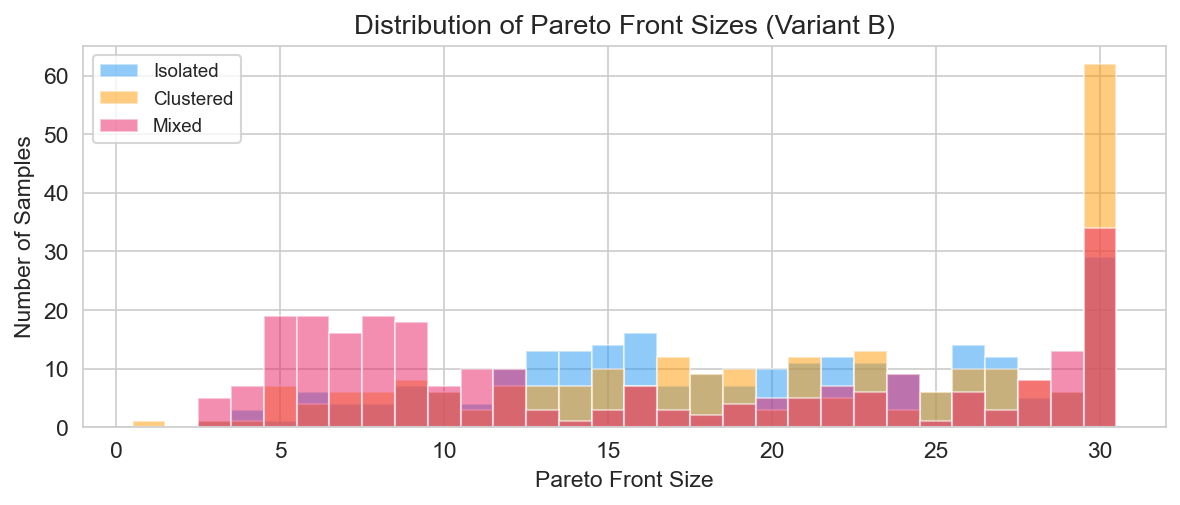

In [8]:
# ============================================================
# FIGURE B1: Histogram of Pareto front sizes
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.arange(0.5, df_b.n_solutions.max() + 1.5, 1)
for st in SCENE_ORDER:
    vals = df_b[df_b.scene_type == st]['n_solutions']
    ax.hist(vals, bins=bins, alpha=0.5, label=st,
            color=SCENE_COLORS[st], edgecolor='white')

ax.set_xlabel('Pareto Front Size')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Pareto Front Sizes (Variant B)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_pareto_front_sizes.pdf'))
plt.show()

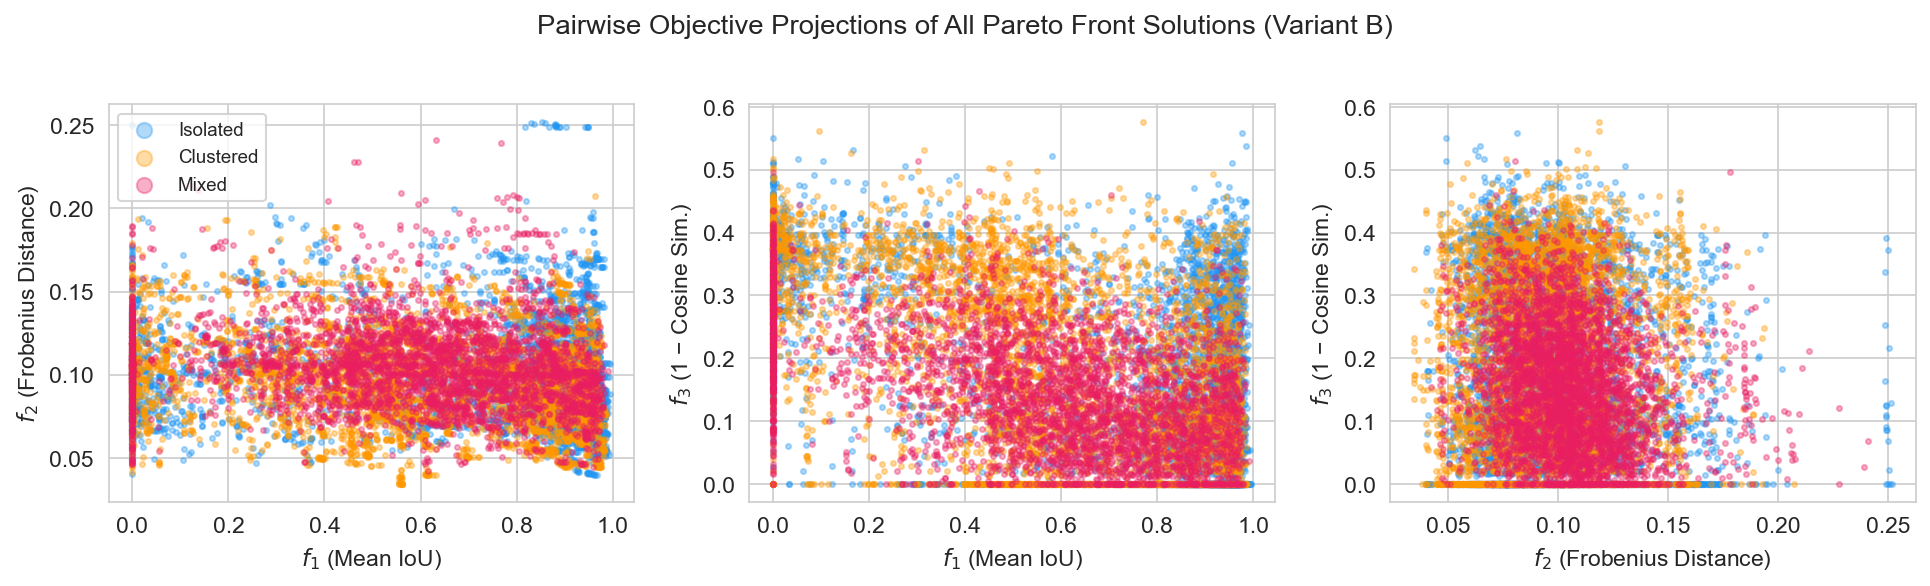

In [9]:
# ============================================================
# FIGURE B2: 2D scatter projections of ALL Pareto front solutions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

pairs = [
    ('iou', 'img_dist', '$f_1$ (Mean IoU)', '$f_2$ (Frobenius Distance)'),
    ('iou', 'txt_dist', '$f_1$ (Mean IoU)', '$f_3$ (1 \u2212 Cosine Sim.)'),
    ('img_dist', 'txt_dist', '$f_2$ (Frobenius Distance)', '$f_3$ (1 \u2212 Cosine Sim.)'),
]

for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    for st in SCENE_ORDER:
        sub = df_b_sols[df_b_sols.scene_type == st]
        ax.scatter(sub[xc], sub[yc], s=6, alpha=0.35,
                   color=SCENE_COLORS[st], label=st)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

axes[0].legend(markerscale=3, fontsize=9)
fig.suptitle('Pairwise Objective Projections of All Pareto Front Solutions (Variant B)', y=1.02)
plt.tight_layout(w_pad=1.5)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_pareto_2d_projections.pdf'))
plt.show()

## Budget Utilization Analysis

In [10]:
# ============================================================
# 6a. Mean total budget utilization per modality
# ============================================================

print('=== Budget Utilization (SWAD*-Optimal Solutions) ===')
print(f'{"Scene Type":<18} {"Img Budget":>11} {"Txt Budget":>11} '
      f'{"Img %":>7} {"Txt %":>7}')
print('-' * 58)
for st in SCENE_ORDER:
    sub = df_b[df_b.scene_type == st]
    ib = sub['swad_img_budget_used']
    tb = sub['swad_txt_budget_used']
    print(f'{st:<18} {ib.mean():>11.4f} {tb.mean():>11.4f} '
          f'{100*ib.mean()/BUDGET_MAX:>6.1f}% {100*tb.mean()/BUDGET_MAX:>6.1f}%')
ib = df_b['swad_img_budget_used']
tb = df_b['swad_txt_budget_used']
print('-' * 58)
print(f'{"Overall":<18} {ib.mean():>11.4f} {tb.mean():>11.4f} '
      f'{100*ib.mean()/BUDGET_MAX:>6.1f}% {100*tb.mean()/BUDGET_MAX:>6.1f}%')

print(f'\nImage budget std: {ib.std():.4f}, min: {ib.min():.4f}, max: {ib.max():.4f}')
print(f'Text  budget std: {tb.std():.4f}, min: {tb.min():.4f}, max: {tb.max():.4f}')

=== Budget Utilization (SWAD*-Optimal Solutions) ===
Scene Type          Img Budget  Txt Budget   Img %   Txt %
----------------------------------------------------------
Isolated                0.3888      0.5301   38.9%   53.0%
Clustered               0.4239      0.5386   42.4%   53.9%
Mixed                   0.4050      0.5561   40.5%   55.6%
----------------------------------------------------------
Overall                 0.4059      0.5416   40.6%   54.2%

Image budget std: 0.2715, min: 0.0003, max: 1.0000
Text  budget std: 0.2638, min: 0.0017, max: 1.0000


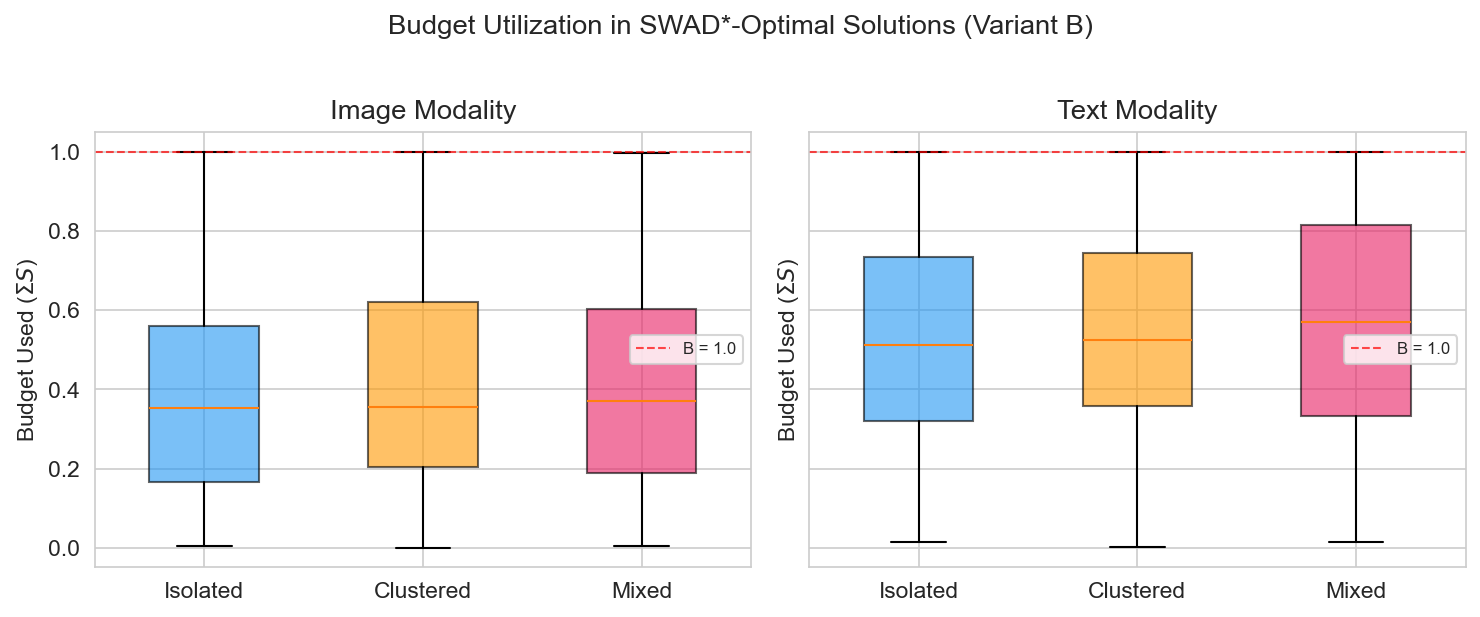

In [11]:
# ============================================================
# FIGURE B3: Budget utilization distributions (box plots)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, col, title in [(axes[0], 'swad_img_budget_used', 'Image Modality'),
                        (axes[1], 'swad_txt_budget_used', 'Text Modality')]:
    data = [df_b[df_b.scene_type == st][col] for st in SCENE_ORDER]
    bp = ax.boxplot(data, labels=SCENE_ORDER, patch_artist=True, widths=0.5)
    for patch, st in zip(bp['boxes'], SCENE_ORDER):
        patch.set_facecolor(SCENE_COLORS[st])
        patch.set_alpha(0.6)
    ax.axhline(BUDGET_MAX, color='red', ls='--', lw=1, alpha=0.7, label=f'B = {BUDGET_MAX}')
    ax.set_ylabel('Budget Used ($\\Sigma S$)')
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle('Budget Utilization in SWAD*-Optimal Solutions (Variant B)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_budget_utilization_box.pdf'))
plt.show()

In [12]:
# ============================================================
# 6b. Per-corruption mean severity allocation (SWAD*-optimal)
# ============================================================

print('=== Per-Corruption Mean Severity (SWAD*-Optimal) ===')

# Image corruptions
print(f'\n  IMAGE CORRUPTIONS (application order):')
print(f'  {"Corruption":<20} {"Mean S":>8} {"Std":>8} {"Med":>8} '
      f'{"Q25":>8} {"Q75":>8} {"Budget Share":>13}')
print(f'  {"-"*72}')
img_budget = df_b['swad_img_budget_used']
for atk in IMAGE_ATTACKS:
    col = f'swad_img_{atk}'
    v = df_b[col]
    # Mean share of modality budget consumed by this corruption
    share = (v / img_budget.replace(0, np.nan)).mean()
    print(f'  {IMG_NICE[atk]:<20} {v.mean():>8.4f} {v.std():>8.4f} '
          f'{v.median():>8.4f} {v.quantile(0.25):>8.4f} '
          f'{v.quantile(0.75):>8.4f} {share:>12.1%}')

# Text corruptions
print(f'\n  TEXT CORRUPTIONS (application order):')
print(f'  {"Corruption":<20} {"Mean S":>8} {"Std":>8} {"Med":>8} '
      f'{"Q25":>8} {"Q75":>8} {"Budget Share":>13}')
print(f'  {"-"*72}')
txt_budget = df_b['swad_txt_budget_used']
for atk in TEXT_ATTACKS:
    col = f'swad_txt_{atk}'
    v = df_b[col]
    share = (v / txt_budget.replace(0, np.nan)).mean()
    print(f'  {TXT_NICE[atk]:<20} {v.mean():>8.4f} {v.std():>8.4f} '
          f'{v.median():>8.4f} {v.quantile(0.25):>8.4f} '
          f'{v.quantile(0.75):>8.4f} {share:>12.1%}')

print(f'\n  Note: all corruptions are applied at every scale -- S=0.0 produces'
      f' non-trivial effects (e.g. JPEG quality=30, gaussian \u03c3=0.03, 10% text prob).')


=== Per-Corruption Mean Severity (SWAD*-Optimal) ===

  IMAGE CORRUPTIONS (application order):
  Corruption             Mean S      Std      Med      Q25      Q75  Budget Share
  ------------------------------------------------------------------------
  Gaussian Noise         0.0625   0.0818   0.0293   0.0071   0.0882        15.6%
  Defocus Blur           0.0736   0.1030   0.0323   0.0090   0.0888        17.6%
  Motion Blur            0.0778   0.0905   0.0422   0.0110   0.1275        20.7%
  Fog Overlay            0.0415   0.0659   0.0117   0.0026   0.0500        10.2%
  Pixelation             0.0642   0.0850   0.0304   0.0080   0.0854        15.8%
  JPEG Compression       0.0862   0.1076   0.0452   0.0104   0.1154        20.1%

  TEXT CORRUPTIONS (application order):
  Corruption             Mean S      Std      Med      Q25      Q75  Budget Share
  ------------------------------------------------------------------------
  Homophone              0.1193   0.1219   0.0740   0.0270   0.1

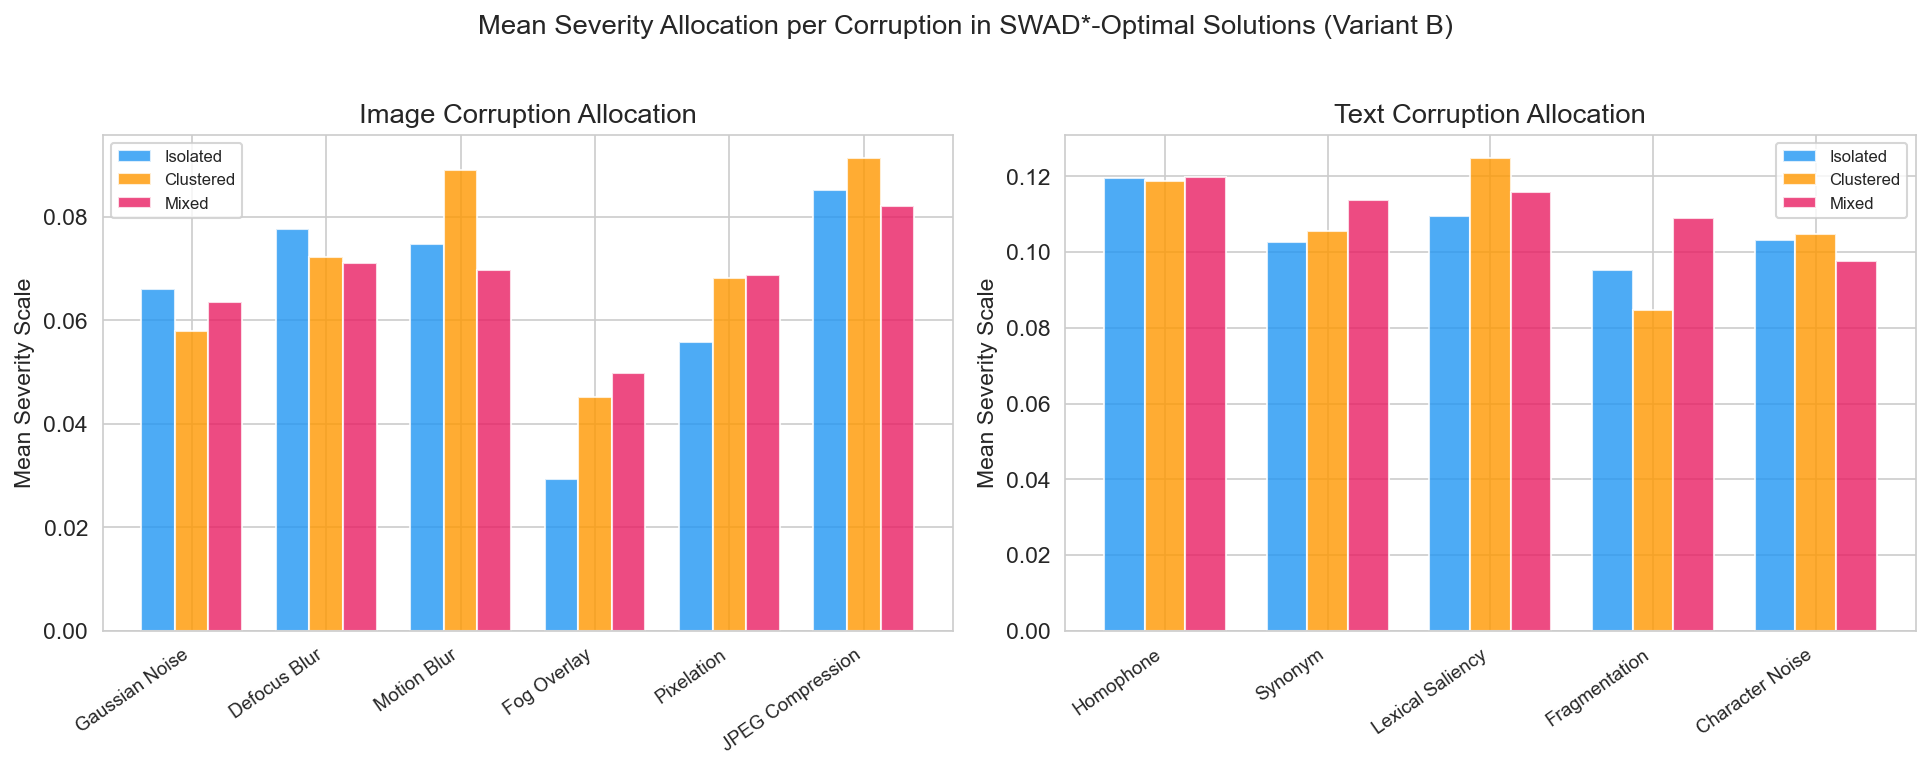

In [13]:
# ============================================================
# FIGURE B4: Stacked bar chart -- mean severity per corruption (SWAD*)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
img_means = {st: [df_b[df_b.scene_type == st][f'swad_img_{a}'].mean() 
                   for a in IMAGE_ATTACKS] for st in SCENE_ORDER}
x = np.arange(N_IMG)
width = 0.25
for i, st in enumerate(SCENE_ORDER):
    ax.bar(x + i * width, img_means[st], width, label=st,
           color=SCENE_COLORS[st], alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([IMG_NICE[a] for a in IMAGE_ATTACKS], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean Severity Scale')
ax.set_title('Image Corruption Allocation')
ax.legend(fontsize=8)

ax = axes[1]
txt_means = {st: [df_b[df_b.scene_type == st][f'swad_txt_{a}'].mean()
                   for a in TEXT_ATTACKS] for st in SCENE_ORDER}
x = np.arange(N_TXT)
for i, st in enumerate(SCENE_ORDER):
    ax.bar(x + i * width, txt_means[st], width, label=st,
           color=SCENE_COLORS[st], alpha=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([TXT_NICE[a] for a in TEXT_ATTACKS], rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Mean Severity Scale')
ax.set_title('Text Corruption Allocation')
ax.legend(fontsize=8)

fig.suptitle('Mean Severity Allocation per Corruption in SWAD*-Optimal Solutions (Variant B)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_severity_allocation_bars.pdf'))
plt.show()

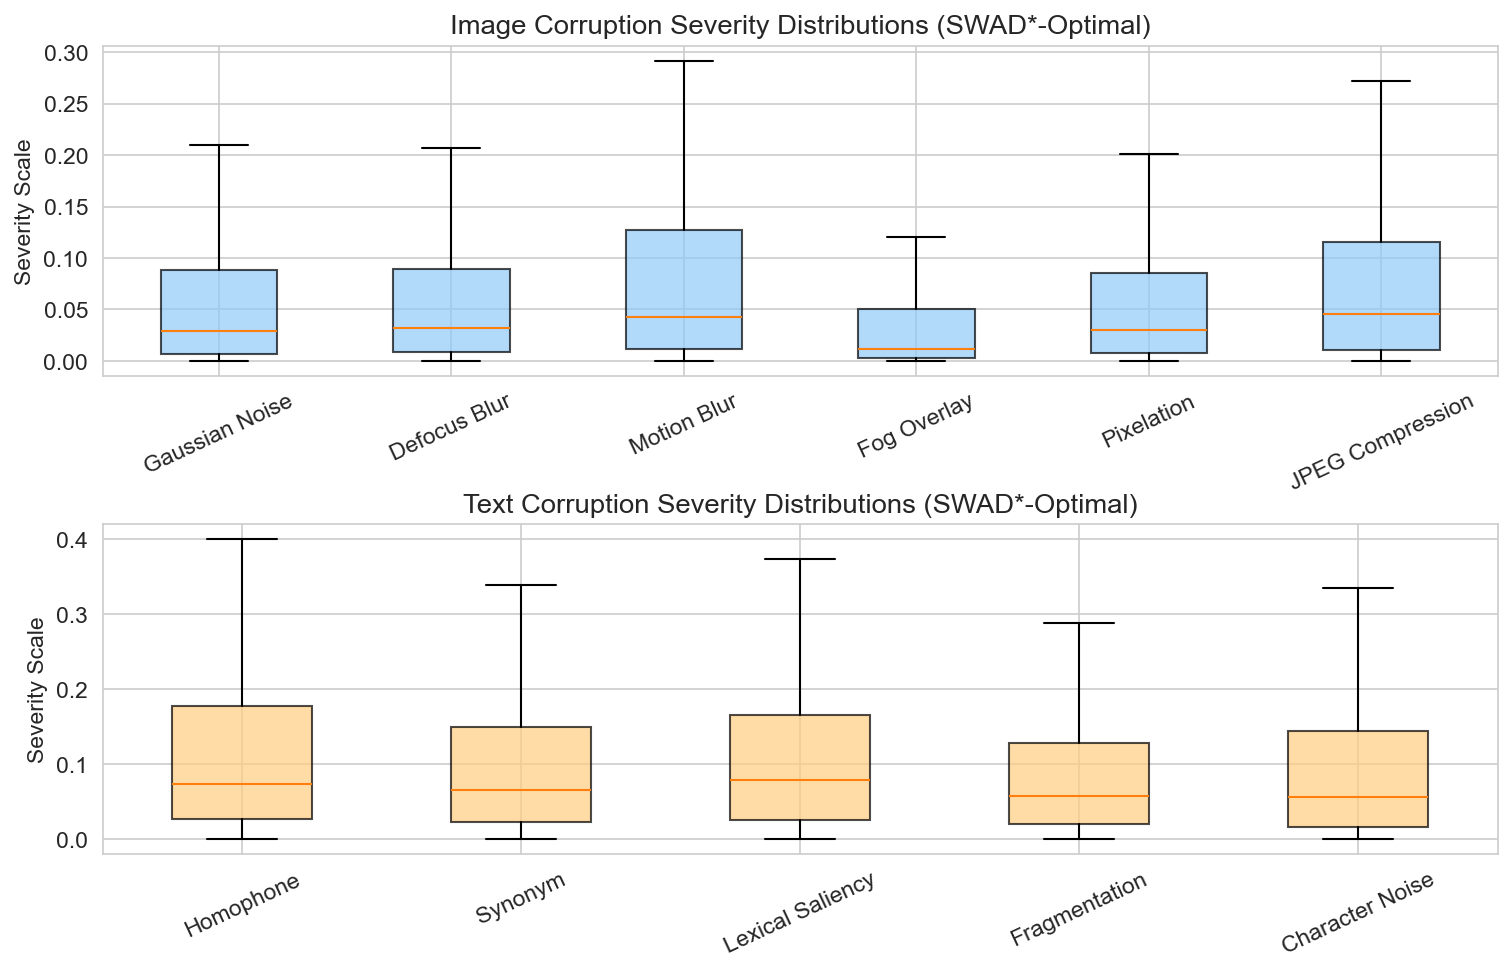

In [14]:
# ============================================================
# FIGURE B5: Box plots -- per-corruption severity distributions
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'hspace': 0.45})

ax = axes[0]
img_data = [df_b[f'swad_img_{a}'] for a in IMAGE_ATTACKS]
bp = ax.boxplot(img_data, labels=[IMG_NICE[a] for a in IMAGE_ATTACKS],
                patch_artist=True, widths=0.5, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#90CAF9')
    patch.set_alpha(0.7)
ax.set_ylabel('Severity Scale')
ax.set_title('Image Corruption Severity Distributions (SWAD*-Optimal)')
ax.tick_params(axis='x', rotation=25)

ax = axes[1]
txt_data = [df_b[f'swad_txt_{a}'] for a in TEXT_ATTACKS]
bp = ax.boxplot(txt_data, labels=[TXT_NICE[a] for a in TEXT_ATTACKS],
                patch_artist=True, widths=0.5, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#FFCC80')
    patch.set_alpha(0.7)
ax.set_ylabel('Severity Scale')
ax.set_title('Text Corruption Severity Distributions (SWAD*-Optimal)')
ax.tick_params(axis='x', rotation=25)

fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_severity_boxplots.pdf'))
plt.show()

In [15]:
# ============================================================
# 6c. Concentration vs. distribution
#
# All corruptions are always applied (S=0 still perturbs), so a binary
# active/inactive classification is meaningless. Instead, budget
# concentration is measured via the Herfindahl-Hirschman Index (HHI)
# and its inverse, the effective corruption count.
#
# HHI = Σ(pₖ)²  where pₖ = Sₖ / Σ Sₖ  (budget share per corruption)
# Effective count = 1 / HHI
#   - Uniform allocation -> HHI = 1/N, eff = N
#   - All budget on one  -> HHI = 1.0, eff = 1
# Max share = max(pₖ)   -> dominant corruption's budget fraction
# ============================================================

print('=== Budget Concentration (HHI-Based) -- SWAD*-Optimal ===')
print(f'{"Scene Type":<18} '
      f'{"HHI Img":>8} {"Eff Img":>8} {"MaxSh Img":>10} '
      f'{"HHI Txt":>8} {"Eff Txt":>8} {"MaxSh Txt":>10}')
print('-' * 74)
for st in SCENE_ORDER:
    sub = df_b[df_b.scene_type == st]
    print(f'{st:<18} '
          f'{sub.swad_hhi_img.mean():>8.3f} {sub.swad_eff_img.mean():>8.2f} '
          f'{sub.swad_maxshare_img.mean():>9.1%} '
          f'{sub.swad_hhi_txt.mean():>8.3f} {sub.swad_eff_txt.mean():>8.2f} '
          f'{sub.swad_maxshare_txt.mean():>9.1%}')
sub = df_b
print('-' * 74)
print(f'{"Overall":<18} '
      f'{sub.swad_hhi_img.mean():>8.3f} {sub.swad_eff_img.mean():>8.2f} '
      f'{sub.swad_maxshare_img.mean():>9.1%} '
      f'{sub.swad_hhi_txt.mean():>8.3f} {sub.swad_eff_txt.mean():>8.2f} '
      f'{sub.swad_maxshare_txt.mean():>9.1%}')

print(f'\n  Reference bounds:')
print(f'    Uniform image:  HHI = {1/N_IMG:.3f}, eff = {N_IMG:.1f}')
print(f'    Uniform text:   HHI = {1/N_TXT:.3f}, eff = {N_TXT:.1f}')
print(f'    Full concentration: HHI = 1.000, eff = 1.0')

pseudo_a_img = (df_b.swad_eff_img < 2.0).mean()
pseudo_a_txt = (df_b.swad_eff_txt < 2.0).mean()
print(f'\n  Fraction with effective count < 2 (pseudo-A concentration):')
print(f'    Image: {100*pseudo_a_img:.1f}%')
print(f'    Text:  {100*pseudo_a_txt:.1f}%')


=== Budget Concentration (HHI-Based) -- SWAD*-Optimal ===
Scene Type          HHI Img  Eff Img  MaxSh Img  HHI Txt  Eff Txt  MaxSh Txt
--------------------------------------------------------------------------
Isolated              0.369     3.04     49.3%    0.370     2.93     49.8%
Clustered             0.368     3.10     49.8%    0.371     2.96     50.0%
Mixed                 0.330     3.35     45.8%    0.343     3.11     46.5%
--------------------------------------------------------------------------
Overall               0.355     3.16     48.3%    0.361     3.00     48.8%

  Reference bounds:
    Uniform image:  HHI = 0.167, eff = 6.0
    Uniform text:   HHI = 0.200, eff = 5.0
    Full concentration: HHI = 1.000, eff = 1.0

  Fraction with effective count < 2 (pseudo-A concentration):
    Image: 14.0%
    Text:  11.6%


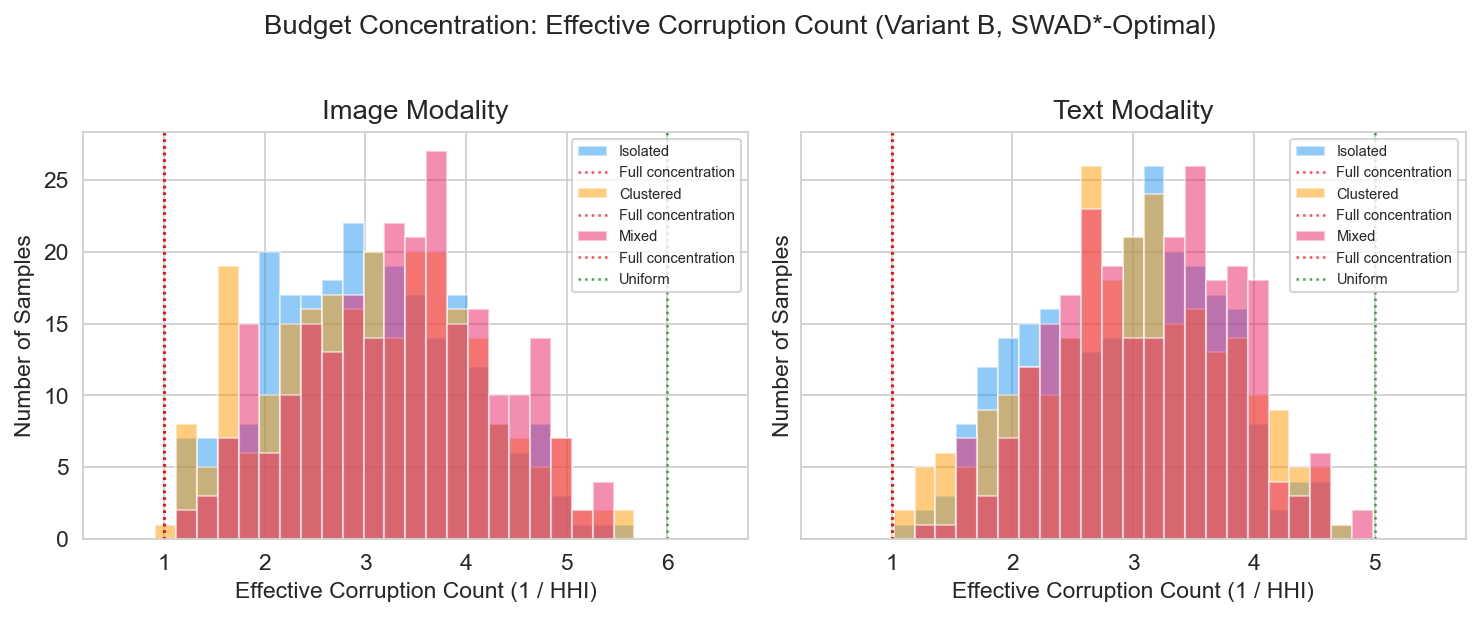

In [16]:
# ============================================================
# FIGURE B6: Effective corruption count distribution per modality
#            (continuous, derived from 1/HHI)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, col, title, n_max in [(axes[0], 'swad_eff_img', 'Image Modality', N_IMG),
                               (axes[1], 'swad_eff_txt', 'Text Modality', N_TXT)]:
    vals = df_b[col].dropna()
    bins = np.linspace(0.5, n_max + 0.5, 30)
    for st in SCENE_ORDER:
        sub_vals = df_b[df_b.scene_type == st][col].dropna()
        ax.hist(sub_vals, bins=bins, alpha=0.5, label=st,
                color=SCENE_COLORS[st], edgecolor='white')
        ax.axvline(1.0, color='red', ls=':', lw=1.2, alpha=0.7, label='Full concentration')
    ax.axvline(n_max, color='green', ls=':', lw=1.2, alpha=0.7, label='Uniform')
    ax.set_xlabel('Effective Corruption Count (1 / HHI)')
    ax.set_ylabel('Number of Samples')
    ax.set_title(title)
    ax.legend(fontsize=7)

fig.suptitle('Budget Concentration: Effective Corruption Count (Variant B, SWAD*-Optimal)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_effective_count_hist.pdf'))
plt.show()


In [17]:
# ============================================================
# 6d. Budget allocation: SWAD*-optimal vs L2-optimal
# ============================================================

print('=== Budget Allocation Comparison: SWAD* vs L2 ===')
print(f'{"":<20} {"SWAD* Img":>10} {"L2 Img":>10} {"SWAD* Txt":>10} {"L2 Txt":>10}')
print('-' * 62)

print(f'{"Mean budget used":<20} '
      f'{df_b.swad_img_budget_used.mean():>10.4f} '
      f'{df_b.l2_img_budget_used.mean():>10.4f} '
      f'{df_b.swad_txt_budget_used.mean():>10.4f} '
      f'{df_b.l2_txt_budget_used.mean():>10.4f}')

print(f'{"Mean HHI":<20} '
      f'{df_b.swad_hhi_img.mean():>10.3f} '
      f'{df_b.l2_hhi_img.mean():>10.3f} '
      f'{df_b.swad_hhi_txt.mean():>10.3f} '
      f'{df_b.l2_hhi_txt.mean():>10.3f}')

print(f'{"Mean eff. count":<20} '
      f'{df_b.swad_eff_img.mean():>10.2f} '
      f'{df_b.l2_eff_img.mean():>10.2f} '
      f'{df_b.swad_eff_txt.mean():>10.2f} '
      f'{df_b.l2_eff_txt.mean():>10.2f}')

print(f'{"Mean max share":<20} '
      f'{df_b.swad_maxshare_img.mean():>9.1%} '
      f'{df_b.l2_maxshare_img.mean():>10.1%} '
      f'{df_b.swad_maxshare_txt.mean():>9.1%} '
      f'{df_b.l2_maxshare_txt.mean():>10.1%}')

print(f'\nPer-corruption mean severity comparison:')
print(f'{"Corruption":<20} {"SWAD* Mean":>11} {"L2 Mean":>11} {"Delta":>8}')
print(f'{"-"*52}')
for atk in IMAGE_ATTACKS:
    s_val = df_b[f'swad_img_{atk}'].mean()
    l_val = df_b[f'l2_img_{atk}'].mean()
    print(f'{IMG_NICE[atk]:<20} {s_val:>11.4f} {l_val:>11.4f} {s_val - l_val:>+8.4f}')
for atk in TEXT_ATTACKS:
    s_val = df_b[f'swad_txt_{atk}'].mean()
    l_val = df_b[f'l2_txt_{atk}'].mean()
    print(f'{TXT_NICE[atk]:<20} {s_val:>11.4f} {l_val:>11.4f} {s_val - l_val:>+8.4f}')


=== Budget Allocation Comparison: SWAD* vs L2 ===
                      SWAD* Img     L2 Img  SWAD* Txt     L2 Txt
--------------------------------------------------------------
Mean budget used         0.4059     0.4155     0.5416     0.5356
Mean HHI                  0.355      0.350      0.361      0.360
Mean eff. count            3.16       3.19       3.00       3.01
Mean max share           48.3%      47.7%     48.8%      48.6%

Per-corruption mean severity comparison:
Corruption            SWAD* Mean     L2 Mean    Delta
----------------------------------------------------
Gaussian Noise            0.0625      0.0639  -0.0014
Defocus Blur              0.0736      0.0763  -0.0027
Motion Blur               0.0778      0.0792  -0.0014
Fog Overlay               0.0415      0.0448  -0.0033
Pixelation                0.0642      0.0652  -0.0009
JPEG Compression          0.0862      0.0861  +0.0001
Homophone                 0.1193      0.1199  -0.0006
Synonym                   0.1074     

## Detection Degradation Results

In [18]:
print('=== Detection Degradation (SWAD*-Optimal, Variant B) ===')
print(f'{"Scene Type":<18} {"Mean IoU_M":>10} {"Med IoU_M":>10} {"Std":>7} '
      f'{"Mean \u03b4_M+":>10} {"IoU=0":>6} {"<0.1":>5} {"\u22640.35":>6}')
print('-' * 78)
for st in SCENE_ORDER:
    sub = df_b[df_b.scene_type == st]
    iou = sub['swad_iou_m']
    dm = sub['swad_delta_m']
    n = len(sub)
    print(f'{st:<18} {iou.mean():>10.4f} {iou.median():>10.4f} {iou.std():>7.4f} '
          f'{dm.mean():>10.4f} '
          f'{(iou == 0).sum():>6} {(iou < 0.1).sum():>5} {(iou <= 0.35).sum():>6}')
sub = df_b
iou = sub['swad_iou_m']
dm = sub['swad_delta_m']
print('-' * 78)
print(f'{"Overall":<18} {iou.mean():>10.4f} {iou.median():>10.4f} {iou.std():>7.4f} '
      f'{dm.mean():>10.4f} '
      f'{(iou == 0).sum():>6} {(iou < 0.1).sum():>5} {(iou <= 0.35).sum():>6}')

=== Detection Degradation (SWAD*-Optimal, Variant B) ===
Scene Type         Mean IoU_M  Med IoU_M     Std  Mean δ_M+  IoU=0  <0.1  ≤0.35
------------------------------------------------------------------------------
Isolated               0.0968     0.0000  0.2224     0.8948    145   203    228
Clustered              0.0731     0.0000  0.1487     0.9095    136   195    239
Mixed                  0.0148     0.0000  0.0572     0.9790    228   236    250
------------------------------------------------------------------------------
Overall                0.0615     0.0000  0.1615     0.9278    509   634    717


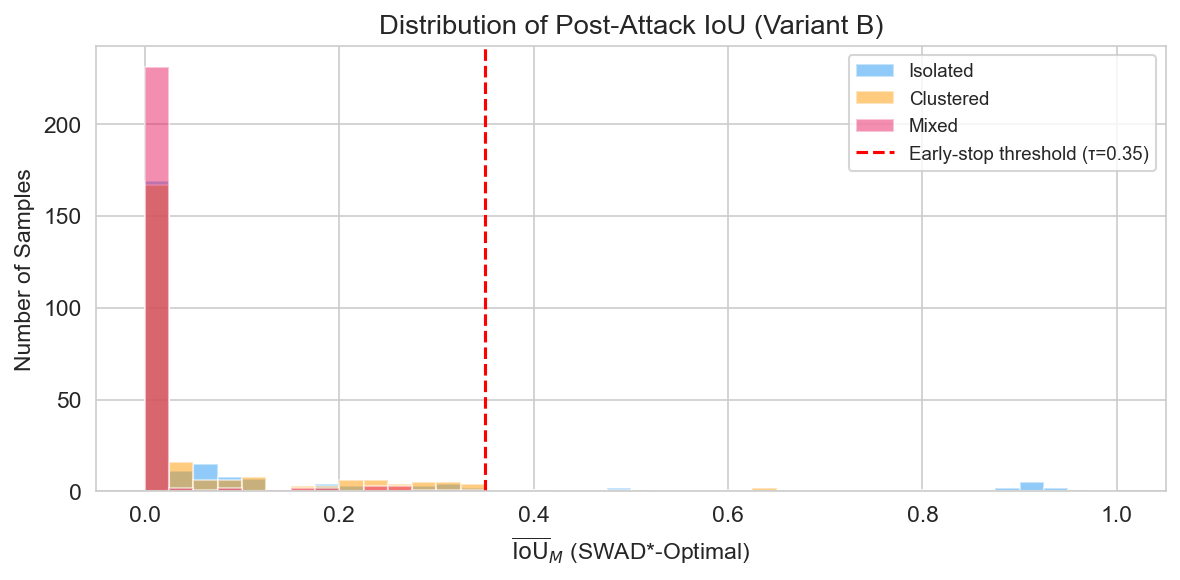

In [19]:
# ============================================================
# FIGURE B7: Post-attack IoU histogram (SWAD*-optimal)
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
for st in SCENE_ORDER:
    vals = df_b[df_b.scene_type == st]['swad_iou_m']
    ax.hist(vals, bins=bins, alpha=0.5, label=st,
            color=SCENE_COLORS[st], edgecolor='white')

ax.axvline(EARLY_STOP_IOU_MAX, color='red', ls='--', lw=1.5,
           label=f'Early-stop threshold (\u03c4={EARLY_STOP_IOU_MAX})')
ax.set_xlabel('$\\overline{\\mathrm{IoU}}_M$ (SWAD*-Optimal)')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Post-Attack IoU (Variant B)')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_post_attack_iou_hist.pdf'))
plt.show()

## Stealth and SWAD* Results

In [20]:
print('=== Stealth Profile (SWAD*-Optimal Solutions, Variant B) ===')
print(f'{"Scene Type":<18} {"d_I mean":>9} {"d_T mean":>9} {"\u03a6 mean":>8} '
      f'{"\u03a6>0.8":>6} {"\u03a6>0.9":>6}')
print('-' * 60)
for st in SCENE_ORDER:
    sub = df_b[df_b.scene_type == st]
    di = sub['swad_img_dist']
    dt = sub['swad_txt_dist']
    phi = sub['swad_phi']
    print(f'{st:<18} {di.mean():>9.4f} {dt.mean():>9.4f} {phi.mean():>8.4f} '
          f'{(phi > 0.8).sum():>6} {(phi > 0.9).sum():>6}')
sub = df_b
print('-' * 60)
print(f'{"Overall":<18} {sub.swad_img_dist.mean():>9.4f} '
      f'{sub.swad_txt_dist.mean():>9.4f} {sub.swad_phi.mean():>8.4f} '
      f'{(sub.swad_phi > 0.8).sum():>6} {(sub.swad_phi > 0.9).sum():>6}')

=== Stealth Profile (SWAD*-Optimal Solutions, Variant B) ===
Scene Type          d_I mean  d_T mean   Φ mean  Φ>0.8  Φ>0.9
------------------------------------------------------------
Isolated              0.0970    0.2716   0.6570     33      8
Clustered             0.0952    0.2518   0.6766     40     15
Mixed                 0.0996    0.2169   0.7046     19      1
------------------------------------------------------------
Overall               0.0973    0.2468   0.6794     92     24


In [21]:
print('\n=== Stealth Frontier: Lowest Achievable IoU at \u03a6 Thresholds (Variant B) ===')
for phi_thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    mask = df_b['swad_phi'] > phi_thresh
    if mask.sum() == 0:
        print(f'  \u03a6 > {phi_thresh:.2f}: no solutions')
    else:
        sub = df_b.loc[mask, 'swad_iou_m']
        print(f'  \u03a6 > {phi_thresh:.2f}: n={mask.sum():>4}, '
              f'min IoU_M={sub.min():.4f}, mean IoU_M={sub.mean():.4f}')


=== Stealth Frontier: Lowest Achievable IoU at Φ Thresholds (Variant B) ===
  Φ > 0.50: n= 741, min IoU_M=0.0000, mean IoU_M=0.0612
  Φ > 0.60: n= 597, min IoU_M=0.0000, mean IoU_M=0.0666
  Φ > 0.70: n= 271, min IoU_M=0.0000, mean IoU_M=0.1021
  Φ > 0.80: n=  92, min IoU_M=0.0000, mean IoU_M=0.2238
  Φ > 0.90: n=  24, min IoU_M=0.0000, mean IoU_M=0.3355
  Φ > 0.95: no solutions


In [22]:
print('=== SWAD* Distribution (Variant B) ===')
print(f'{"Scene Type":<18} {"Mean":>7} {"Std":>7} {"Median":>7} {"Q25":>7} {"Q75":>7} '
      f'{"Min":>7} {"Max":>7}')
print('-' * 70)
for st in SCENE_ORDER:
    v = df_b[df_b.scene_type == st]['swad_star']
    print(f'{st:<18} {v.mean():>7.4f} {v.std():>7.4f} {v.median():>7.4f} '
          f'{v.quantile(0.25):>7.4f} {v.quantile(0.75):>7.4f} '
          f'{v.min():>7.4f} {v.max():>7.4f}')
v = df_b['swad_star']
print('-' * 70)
print(f'{"Overall":<18} {v.mean():>7.4f} {v.std():>7.4f} {v.median():>7.4f} '
      f'{v.quantile(0.25):>7.4f} {v.quantile(0.75):>7.4f} '
      f'{v.min():>7.4f} {v.max():>7.4f}')

=== SWAD* Distribution (Variant B) ===
Scene Type            Mean     Std  Median     Q25     Q75     Min     Max
----------------------------------------------------------------------
Isolated            0.5763  0.1644  0.6055  0.5469  0.6504  0.0001  0.9183
Clustered           0.6081  0.1404  0.6202  0.5581  0.6792  0.0018  0.9093
Mixed               0.6898  0.0844  0.6975  0.6516  0.7354  0.3291  0.9129
----------------------------------------------------------------------
Overall             0.6248  0.1421  0.6432  0.5746  0.7038  0.0001  0.9183


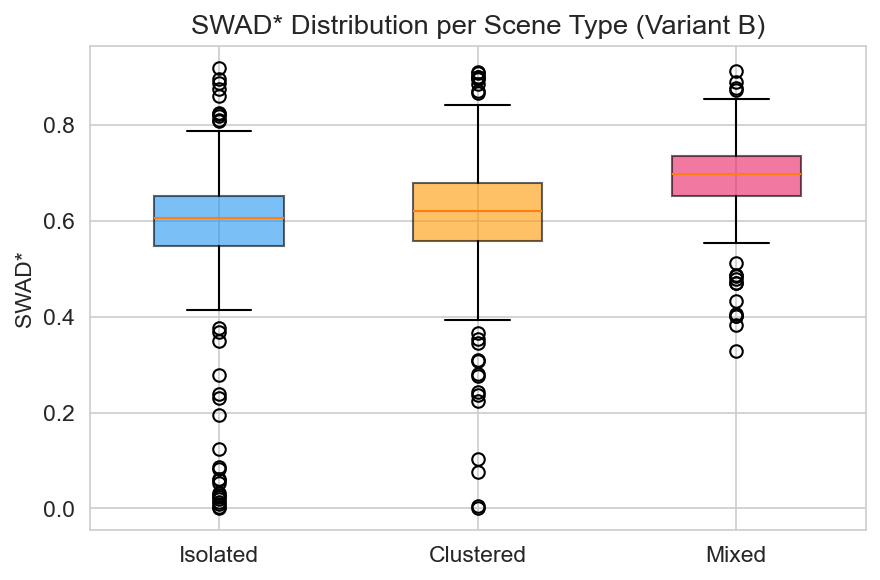

In [23]:
# ============================================================
# FIGURE B8: SWAD* box plot per scene type
# ============================================================

fig, ax = plt.subplots(figsize=(6, 4))
data = [df_b[df_b.scene_type == st]['swad_star'] for st in SCENE_ORDER]
bp = ax.boxplot(data, labels=SCENE_ORDER, patch_artist=True, widths=0.5)
for patch, st in zip(bp['boxes'], SCENE_ORDER):
    patch.set_facecolor(SCENE_COLORS[st])
    patch.set_alpha(0.6)
ax.set_ylabel('SWAD*')
ax.set_title('SWAD* Distribution per Scene Type (Variant B)')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_swad_star_boxplot.pdf'))
plt.show()

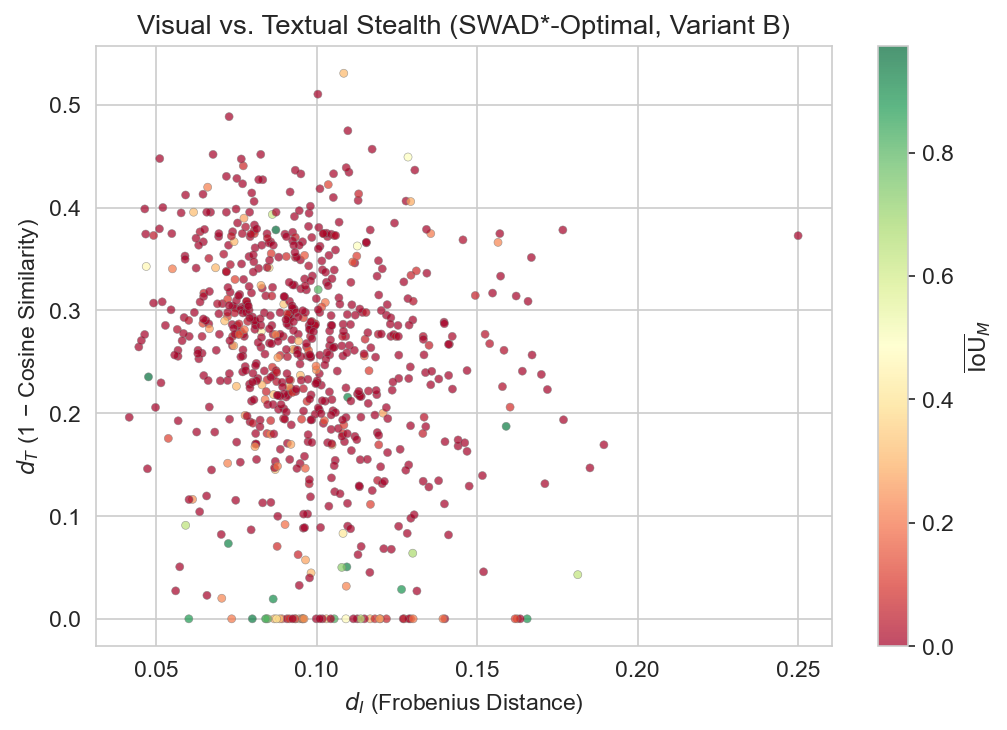

In [24]:
# ============================================================
# FIGURE B9: 2D scatter -- d_I vs d_T colored by IoU_M
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(df_b['swad_img_dist'], df_b['swad_txt_dist'],
                c=df_b['swad_iou_m'], cmap='RdYlGn', s=15, alpha=0.7,
                edgecolors='grey', linewidths=0.3)
ax.set_xlabel('$d_I$ (Frobenius Distance)')
ax.set_ylabel('$d_T$ (1 \u2212 Cosine Similarity)')
ax.set_title('Visual vs. Textual Stealth (SWAD*-Optimal, Variant B)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('$\\overline{\\mathrm{IoU}}_M$')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_di_vs_dt_scatter.pdf'))
plt.show()

## Early Stopping Behavior

In [25]:
print('=== Early Stopping Statistics (Variant B) ===')
n_es = df_b['early_stopped'].sum()
print(f'Total early-stopped: {n_es}/{len(df_b)} ({100*n_es/len(df_b):.1f}%)\n')

print(f'{"Scene Type":<18} {"ES Count":>9} {"ES Rate":>8} {"Mean Gen":>9} '
      f'{"Med Gen":>8} {"Min Gen":>8} {"Max Gen":>8}')
print('-' * 72)
for st in SCENE_ORDER:
    sub = df_b[df_b.scene_type == st]
    es = sub[sub.early_stopped]
    n = len(es)
    rate = 100 * n / len(sub)
    if n > 0:
        gens = es['early_stop_gen']
        print(f'{st:<18} {n:>5}/{len(sub):<3} {rate:>7.1f}% '
              f'{gens.mean():>9.1f} {gens.median():>8.0f} '
              f'{gens.min():>8} {gens.max():>8}')
    else:
        print(f'{st:<18} {n:>5}/{len(sub):<3} {rate:>7.1f}%     --        --        --        --')

=== Early Stopping Statistics (Variant B) ===
Total early-stopped: 376/750 (50.1%)

Scene Type          ES Count  ES Rate  Mean Gen  Med Gen  Min Gen  Max Gen
------------------------------------------------------------------------
Isolated              77/250    30.8%       6.3        5      1.0     15.0
Clustered            119/250    47.6%       4.6        3      1.0     15.0
Mixed                180/250    72.0%       2.3        1      1.0     13.0


In [26]:
es_mask = df_b['early_stopped']
print('\n=== SWAD* Quality: Early-Stopped vs. Full-Run (Variant B) ===')
print(f'{"Group":<18} {"N":>5} {"Mean SWAD*":>11} {"Med SWAD*":>11} {"Mean IoU_M":>11}')
print('-' * 60)
for label, mask in [('Early-stopped', es_mask), ('Full-run', ~es_mask)]:
    sub = df_b[mask]
    if len(sub) > 0:
        print(f'{label:<18} {len(sub):>5} {sub.swad_star.mean():>11.4f} '
              f'{sub.swad_star.median():>11.4f} {sub.swad_iou_m.mean():>11.4f}')
    else:
        print(f'{label:<18}     0          \u2014            \u2014            \u2014')


=== SWAD* Quality: Early-Stopped vs. Full-Run (Variant B) ===
Group                  N  Mean SWAD*   Med SWAD*  Mean IoU_M
------------------------------------------------------------
Early-stopped        376      0.6671      0.6692      0.0405
Full-run             374      0.5822      0.6032      0.0827


In [27]:
agree_rate = df_b['l2_swad_agree'].mean()
print(f'\n=== L2 vs. SWAD* Agreement (Variant B) ===')
print(f'Same solution selected: {df_b.l2_swad_agree.sum()}/{len(df_b)} '
      f'({100*agree_rate:.1f}%)')


=== L2 vs. SWAD* Agreement (Variant B) ===
Same solution selected: 666/750 (88.8%)


## Load Variant A Results for Comparison

In [28]:
df_a = pd.read_csv(VARIANT_A_CSV)
print(f'Loaded Variant A: {len(df_a)} samples')
print(f'Samples per scene type:')
print(df_a.groupby('scene_type').size().reindex(SCENE_ORDER))

a_keys = set(zip(df_a['scene_type'], df_a['sample_id']))
b_keys = set(zip(df_b['scene_type'], df_b['sample_id']))
assert a_keys == b_keys, (
    f'Sample key mismatch! A-only: {len(a_keys - b_keys)}, B-only: {len(b_keys - a_keys)}')
print(f'\n\u2713 Perfect sample alignment between Variant A and B (N={len(a_keys)})')

Loaded Variant A: 750 samples
Samples per scene type:
scene_type
Isolated     250
Clustered    250
Mixed        250
dtype: int64

✓ Perfect sample alignment between Variant A and B (N=750)


In [29]:
cols_a = {
    'swad_star':         'swad_star_a',
    'swad_iou_m':        'swad_iou_m_a',
    'swad_img_dist':     'swad_img_dist_a',
    'swad_txt_dist':     'swad_txt_dist_a',
    'swad_phi':          'swad_phi_a',
    'swad_delta_m':      'swad_delta_m_a',
    'early_stopped':     'early_stopped_a',
    'early_stop_gen':    'early_stop_gen_a',
    'total_evaluations': 'total_evaluations_a',
    'n_solutions':       'n_solutions_a',
    'swad_runtime':      'swad_runtime_a',
    'swad_token_count':  'swad_token_count_a',
    'swad_raw_tokens':   'swad_raw_tokens_a',
}

cols_b = {
    'swad_star':         'swad_star_b',
    'swad_iou_m':        'swad_iou_m_b',
    'swad_img_dist':     'swad_img_dist_b',
    'swad_txt_dist':     'swad_txt_dist_b',
    'swad_phi':          'swad_phi_b',
    'swad_delta_m':      'swad_delta_m_b',
    'early_stopped':     'early_stopped_b',
    'early_stop_gen':    'early_stop_gen_b',
    'total_evaluations': 'total_evaluations_b',
    'n_solutions':       'n_solutions_b',
    'swad_runtime':      'swad_runtime_b',
    'swad_token_count':  'swad_token_count_b',
    'swad_raw_tokens':   'swad_raw_tokens_b',
}

df_a_sub = df_a[['scene_type', 'sample_id', 'baseline_iou'] + list(cols_a.keys())].rename(columns=cols_a)
df_b_sub = df_b[['scene_type', 'sample_id'] + list(cols_b.keys())].rename(columns=cols_b)

df_paired = df_a_sub.merge(df_b_sub, on=['scene_type', 'sample_id'], how='inner')
assert len(df_paired) == 750, f'Expected 750 paired samples, got {len(df_paired)}'
print(f'Built paired DataFrame: {len(df_paired)} samples')

df_paired['swad_delta'] = df_paired['swad_star_b'] - df_paired['swad_star_a']
df_paired['iou_delta']  = df_paired['swad_iou_m_b'] - df_paired['swad_iou_m_a']

Built paired DataFrame: 750 samples


## Central Comparison Table (Variant A vs. Variant B)

In [30]:
# ============================================================
# Central comparison table
# ============================================================

def comparison_row(label, col_a, col_b, fmt='.4f', agg='mean'):
    """Print a comparison row for overall and per-scene-type."""
    parts = [f'{label:<25}']
    for st in SCENE_ORDER + ['Overall']:
        sub = df_paired[df_paired.scene_type == st] if st != 'Overall' else df_paired
        if agg == 'mean':
            va = sub[col_a].mean()
            vb = sub[col_b].mean()
        elif agg == 'median':
            va = sub[col_a].median()
            vb = sub[col_b].median()
        elif agg == 'rate':
            va = sub[col_a].mean()
            vb = sub[col_b].mean()
            fmt = '.1%'
        parts.append(f'{va:{fmt}} | {vb:{fmt}}')
    print('  '.join(parts))


print('=' * 120)
print('CENTRAL COMPARISON TABLE: Variant A vs. Variant B')
print('Format: A | B per cell')
print('=' * 120)

header = f'{"Metric":<25}'
for st in SCENE_ORDER + ['Overall']:
    header += f'  {st:>20}'
print(header)
print('-' * 120)

comparison_row('Mean front size', 'n_solutions_a', 'n_solutions_b', '.1f')

comparison_row('Mean IoU_M', 'swad_iou_m_a', 'swad_iou_m_b')
comparison_row('Mean \u03b4_M+', 'swad_delta_m_a', 'swad_delta_m_b')

comparison_row('Mean d_I', 'swad_img_dist_a', 'swad_img_dist_b')
comparison_row('Mean d_T', 'swad_txt_dist_a', 'swad_txt_dist_b')
comparison_row('Mean \u03a6', 'swad_phi_a', 'swad_phi_b')

comparison_row('Mean SWAD*', 'swad_star_a', 'swad_star_b')
comparison_row('Median SWAD*', 'swad_star_a', 'swad_star_b', agg='median')

comparison_row('Early-stop rate', 'early_stopped_a', 'early_stopped_b', agg='rate')

comparison_row('Mean evaluations', 'total_evaluations_a', 'total_evaluations_b', '.0f')

CENTRAL COMPARISON TABLE: Variant A vs. Variant B
Format: A | B per cell
Metric                                 Isolated             Clustered                 Mixed               Overall
------------------------------------------------------------------------------------------------------------------------
Mean front size            22.3 | 19.3  18.6 | 20.6  12.5 | 15.8  17.8 | 18.5
Mean IoU_M                 0.2085 | 0.0968  0.1209 | 0.0731  0.0593 | 0.0148  0.1295 | 0.0615
Mean δ_M+                  0.7740 | 0.8948  0.8514 | 0.9095  0.9194 | 0.9790  0.8483 | 0.9278
Mean d_I                   0.0672 | 0.0970  0.0627 | 0.0952  0.0698 | 0.0996  0.0666 | 0.0973
Mean d_T                   0.1976 | 0.2716  0.2095 | 0.2518  0.2083 | 0.2169  0.2051 | 0.2468
Mean Φ                     0.7457 | 0.6570  0.7399 | 0.6766  0.7365 | 0.7046  0.7407 | 0.6794
Mean SWAD*                 0.5501 | 0.5763  0.6206 | 0.6081  0.6744 | 0.6898  0.6151 | 0.6248
Median SWAD*               0.6154 | 0.6055  0.6379

In [31]:
print('\n=== Failure Rate Comparison ===')
print(f'{"Threshold":<20} {"A Overall":>10} {"B Overall":>10} {"Delta":>8}')
print('-' * 50)
for label, threshold, op in [('IoU = 0', 0.0, 'eq'),
                              ('IoU < 0.1', 0.1, 'lt'),
                              ('IoU \u2264 0.35', 0.35, 'le')]:
    if op == 'eq':
        ra = (df_paired['swad_iou_m_a'] == threshold).mean()
        rb = (df_paired['swad_iou_m_b'] == threshold).mean()
    elif op == 'lt':
        ra = (df_paired['swad_iou_m_a'] < threshold).mean()
        rb = (df_paired['swad_iou_m_b'] < threshold).mean()
    else:
        ra = (df_paired['swad_iou_m_a'] <= threshold).mean()
        rb = (df_paired['swad_iou_m_b'] <= threshold).mean()
    print(f'{label:<20} {100*ra:>9.1f}% {100*rb:>9.1f}% {100*(rb-ra):>+7.1f}pp')


=== Failure Rate Comparison ===
Threshold             A Overall  B Overall    Delta
--------------------------------------------------
IoU = 0                   46.5%      67.9%   +21.3pp
IoU < 0.1                 67.1%      84.5%   +17.5pp
IoU ≤ 0.35                89.1%      95.6%    +6.5pp


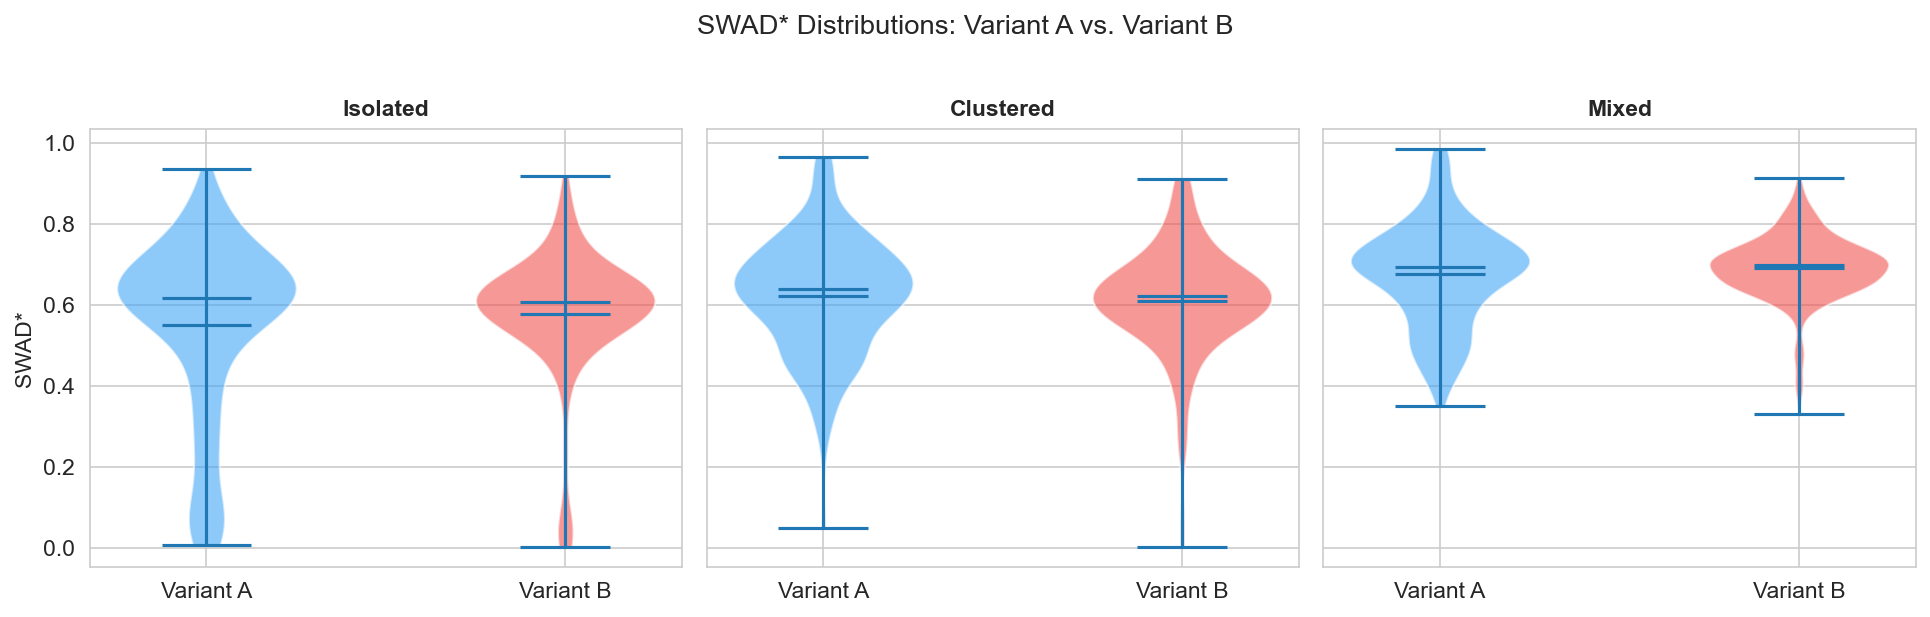

In [32]:
# ============================================================
# FIGURE B10: Paired violin -- SWAD* for A vs B, faceted by scene type
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for ax, st in zip(axes, SCENE_ORDER):
    sub = df_paired[df_paired.scene_type == st]
    parts = ax.violinplot([sub['swad_star_a'], sub['swad_star_b']],
                          positions=[1, 2], showmeans=True, showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(['#42A5F5', '#EF5350'][i])
        pc.set_alpha(0.6)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Variant A', 'Variant B'])
    ax.set_title(st, fontsize=11, fontweight='bold')

axes[0].set_ylabel('SWAD*')
fig.suptitle('SWAD* Distributions: Variant A vs. Variant B', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_swad_violin_comparison_simple.pdf'))
plt.show()

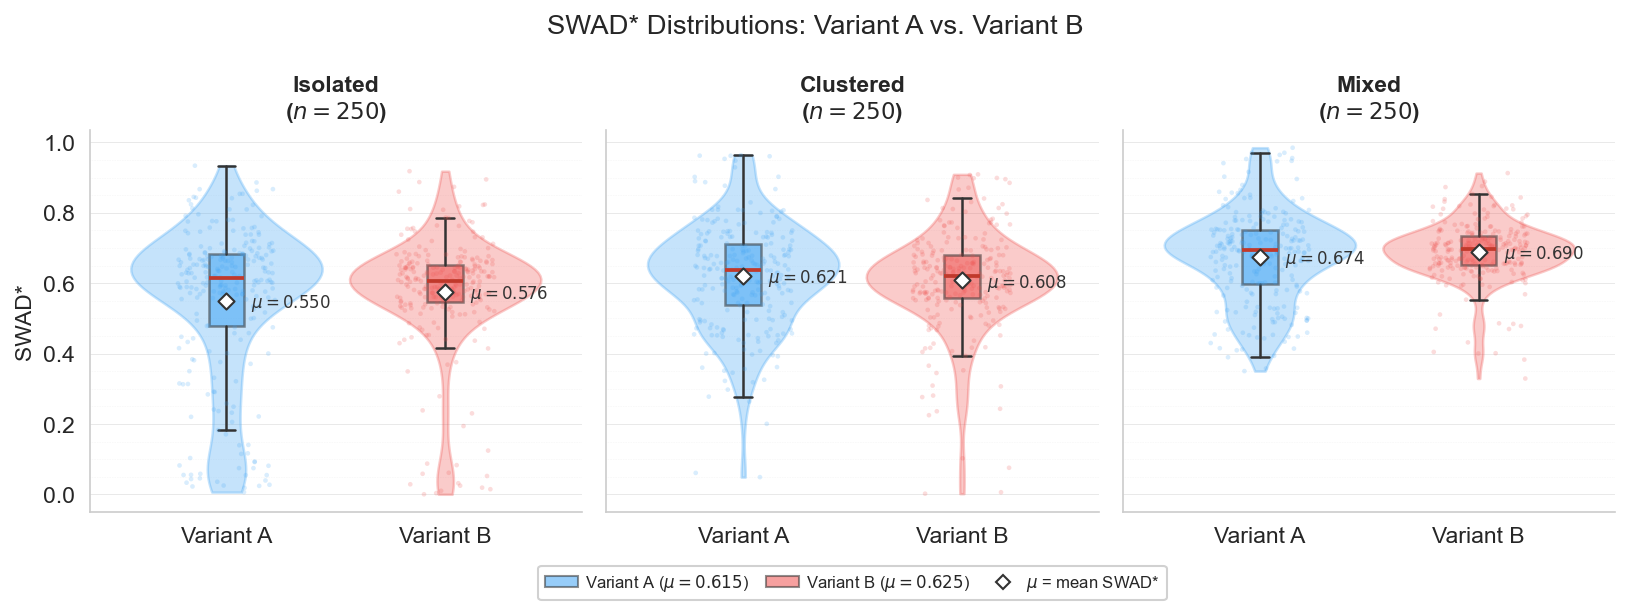

In [33]:
# ============================================================
# FIGURE B10: Paired violin -- SWAD* for A vs B, faceted by scene type
#             (matches Baseline notebook style: violin + box + strip + mean diamonds)
# ============================================================

VARIANT_COLORS = {'A': '#42A5F5', 'B': '#EF5350'}
rng = np.random.default_rng(42)

fig, axes = plt.subplots(1, 3, figsize=(11, 4.25), sharey=True)

for ax, st in zip(axes, SCENE_ORDER):
    sub = df_paired[df_paired.scene_type == st]
    data_a = sub['swad_star_a'].values
    data_b = sub['swad_star_b'].values
    data_arrays = [data_a, data_b]
    positions = [1, 1.8]
    variant_keys = ['A', 'B']

    # --- Violins (transparent, no built-in stats) ---
    parts = ax.violinplot(data_arrays, positions=positions,
                          showmeans=False, showmedians=False,
                          showextrema=False, widths=0.7)
    for i, body in enumerate(parts['bodies']):
        c = VARIANT_COLORS[variant_keys[i]]
        body.set_facecolor(c)
        body.set_edgecolor(c)
        body.set_alpha(0.30)
        body.set_linewidth(1.2)

    # --- Box plots (narrow, overlaid) ---
    bp = ax.boxplot(data_arrays, positions=positions, widths=0.13,
                    patch_artist=True, showfliers=False, showcaps=True,
                    whiskerprops=dict(linewidth=1.2, color='#333'),
                    capprops=dict(linewidth=1.2, color='#333'),
                    medianprops=dict(linewidth=1.8, color='#C0392B', zorder=5),
                    boxprops=dict(linewidth=1.2))
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(VARIANT_COLORS[variant_keys[i]])
        patch.set_alpha(0.55)
        patch.set_edgecolor('#333')

    # --- Jittered strip dots ---
    for i, (arr, pos) in enumerate(zip(data_arrays, positions)):
        jitter = rng.uniform(-0.18, 0.18, size=len(arr))
        ax.scatter(pos + jitter, arr, s=5, alpha=0.20,
                   color=VARIANT_COLORS[variant_keys[i]],
                   edgecolors='none', zorder=2, rasterized=True)

    # --- Mean diamonds with annotation ---
    for i, (arr, pos) in enumerate(zip(data_arrays, positions)):
        mu = np.mean(arr)
        ax.scatter(pos, mu, marker='D', s=30, color='white',
                   edgecolors='#333', linewidths=1.0, zorder=6)
        ax.annotate(f'$\\mu = {mu:.3f}$', xy=(pos, mu),
                    xytext=(12, -1), textcoords='offset points',
                    fontsize=8, color='#333', va='center')

    # --- Axes ---
    ax.set_xticks(positions)
    ax.set_xticklabels(['Variant A', 'Variant B'])
    ax.set_title(f'{st}\n($n = {len(sub)}$)', fontsize=11, fontweight='bold')
    ax.yaxis.grid(True, which='major', linestyle='-', linewidth=0.4, alpha=0.5)
    ax.yaxis.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.3)
    ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
    ax.set_axisbelow(True)
    ax.xaxis.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('SWAD*')

# --- Shared legend ---
legend_elements = [
    Patch(facecolor=VARIANT_COLORS['A'], alpha=0.55, edgecolor='#333',
          label=f'Variant A ($\\mu = {df_paired.swad_star_a.mean():.3f}$)'),
    Patch(facecolor=VARIANT_COLORS['B'], alpha=0.55, edgecolor='#333',
          label=f'Variant B ($\\mu = {df_paired.swad_star_b.mean():.3f}$)'),
    Line2D([0], [0], marker='D', color='white', markeredgecolor='#333',
           markersize=5, linewidth=0,
           label='$\\mu$ = mean SWAD*'),
]
axes[1].legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=True,
               framealpha=0.9, edgecolor='#ccc', fontsize=8,
               columnspacing=1.0, handletextpad=0.4)

fig.suptitle('SWAD* Distributions: Variant A vs. Variant B', y=0.98)
fig.tight_layout()
fig.subplots_adjust(bottom=0.20, wspace=0.05)
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_swad_violin_comparison.pdf'))
plt.show()


## Variant Comparison and Synthesis

In [34]:
# ============================================================
# 12a. Win / Loss / Tie counts
# ============================================================

TIE_TOLERANCE = 0.01

df_paired['winner'] = np.where(
    df_paired['swad_delta'] > TIE_TOLERANCE, 'B',
    np.where(df_paired['swad_delta'] < -TIE_TOLERANCE, 'A', 'Tie')
)

print('=== Win / Loss / Tie (SWAD*, |\u0394| < 0.01 = Tie) ===')
print(f'{"Scene Type":<18} {"A Wins":>8} {"B Wins":>8} {"Tie":>8} '
      f'{"A Win%":>8} {"B Win%":>8} {"Mean \u0394":>8}')
print('-' * 70)
for st in SCENE_ORDER + ['Overall']:
    sub = df_paired[df_paired.scene_type == st] if st != 'Overall' else df_paired
    n = len(sub)
    a_wins = (sub.winner == 'A').sum()
    b_wins = (sub.winner == 'B').sum()
    ties   = (sub.winner == 'Tie').sum()
    mean_d = sub['swad_delta'].mean()
    print(f'{st:<18} {a_wins:>8} {b_wins:>8} {ties:>8} '
          f'{100*a_wins/n:>7.1f}% {100*b_wins/n:>7.1f}% {mean_d:>+8.4f}')

=== Win / Loss / Tie (SWAD*, |Δ| < 0.01 = Tie) ===
Scene Type           A Wins   B Wins      Tie   A Win%   B Win%   Mean Δ
----------------------------------------------------------------------
Isolated                138       91       21    55.2%    36.4%  +0.0262
Clustered               144       87       19    57.6%    34.8%  -0.0125
Mixed                   113      116       21    45.2%    46.4%  +0.0154
Overall                 395      294       61    52.7%    39.2%  +0.0097


In [35]:
# ============================================================
# 12b. Wilcoxon signed-rank test on paired SWAD* differences
# ============================================================

diffs = df_paired['swad_delta'].values
nonzero = diffs[diffs != 0]
if len(nonzero) > 0:
    stat, p_val = stats.wilcoxon(nonzero, alternative='two-sided')
    print(f'\n=== Wilcoxon Signed-Rank Test (Overall) ===')
    print(f'  N non-zero pairs: {len(nonzero)}')
    print(f'  Test statistic:   {stat:.1f}')
    print(f'  p-value:          {p_val:.2e}')
    print(f'  Mean SWAD*(B) - SWAD*(A): {diffs.mean():+.4f}')
    print(f'  Median difference:        {np.median(diffs):+.4f}')
    if p_val < 0.05:
        direction = 'B > A' if np.median(nonzero) > 0 else 'A > B'
        print(f'  \u2192 Significant at \u03b1=0.05 ({direction})')
    else:
        print(f'  \u2192 Not significant at \u03b1=0.05')

print(f'\n  Per-scene-type Wilcoxon:')
for st in SCENE_ORDER:
    sub_diffs = df_paired[df_paired.scene_type == st]['swad_delta'].values
    nz = sub_diffs[sub_diffs != 0]
    if len(nz) >= 10:
        s, p = stats.wilcoxon(nz, alternative='two-sided')
        print(f'  {st:<12}  p={p:.2e}  mean\u0394={sub_diffs.mean():+.4f}  '
              f'med\u0394={np.median(sub_diffs):+.4f}')
    else:
        print(f'  {st:<12}  insufficient non-zero pairs ({len(nz)})')


=== Wilcoxon Signed-Rank Test (Overall) ===
  N non-zero pairs: 750
  Test statistic:   133514.5
  p-value:          2.19e-01
  Mean SWAD*(B) - SWAD*(A): +0.0097
  Median difference:        -0.0168
  → Not significant at α=0.05

  Per-scene-type Wilcoxon:
  Isolated      p=2.93e-01  meanΔ=+0.0262  medΔ=-0.0210
  Clustered     p=1.09e-02  meanΔ=-0.0125  medΔ=-0.0232
  Mixed         p=1.43e-01  meanΔ=+0.0154  medΔ=+0.0019


In [36]:
# ============================================================
# 12c. Characterize when each variant wins
# ============================================================

print('\n=== Characterization of A-wins vs B-wins ===')

for winner_label, winner_code in [('A wins', 'A'), ('B wins', 'B')]:
    sub = df_paired[df_paired.winner == winner_code]
    if len(sub) == 0:
        print(f'\n  {winner_label}: 0 samples')
        continue
    print(f'\n  {winner_label} (N={len(sub)}):')
    
    # Scene type distribution
    st_counts = sub.scene_type.value_counts()
    st_str = ', '.join(f'{k}: {v} ({100*v/len(sub):.0f}%)' 
                       for k, v in st_counts.reindex(SCENE_ORDER).dropna().items())
    print(f'    Scene types: {st_str}')
    
    # Baseline IoU range
    print(f'    Baseline IoU: mean={sub.baseline_iou.mean():.3f}, '
          f'Q25={sub.baseline_iou.quantile(0.25):.3f}, '
          f'Q75={sub.baseline_iou.quantile(0.75):.3f}')
    
    # SWAD* and stealth
    print(f'    Mean SWAD*(A)={sub.swad_star_a.mean():.4f}, '
          f'SWAD*(B)={sub.swad_star_b.mean():.4f}')
    print(f'    Mean d_I: A={sub.swad_img_dist_a.mean():.4f}, '
          f'B={sub.swad_img_dist_b.mean():.4f}')
    print(f'    Mean d_T: A={sub.swad_txt_dist_a.mean():.4f}, '
          f'B={sub.swad_txt_dist_b.mean():.4f}')
    print(f'    Mean \u03a6:   A={sub.swad_phi_a.mean():.4f}, '
          f'B={sub.swad_phi_b.mean():.4f}')


=== Characterization of A-wins vs B-wins ===

  A wins (N=395):
    Scene types: Isolated: 138 (35%), Clustered: 144 (36%), Mixed: 113 (29%)
    Baseline IoU: mean=0.863, Q25=0.809, Q75=0.955
    Mean SWAD*(A)=0.6884, SWAD*(B)=0.5870
    Mean d_I: A=0.0609, B=0.0977
    Mean d_T: A=0.2025, B=0.2560
    Mean Φ:   A=0.7474, B=0.6707

  B wins (N=294):
    Scene types: Isolated: 91 (31%), Clustered: 87 (30%), Mixed: 116 (39%)
    Baseline IoU: mean=0.822, Q25=0.715, Q75=0.944
    Mean SWAD*(A)=0.5150, SWAD*(B)=0.6760
    Mean d_I: A=0.0750, B=0.0989
    Mean d_T: A=0.2037, B=0.2339
    Mean Φ:   A=0.7357, B=0.6897


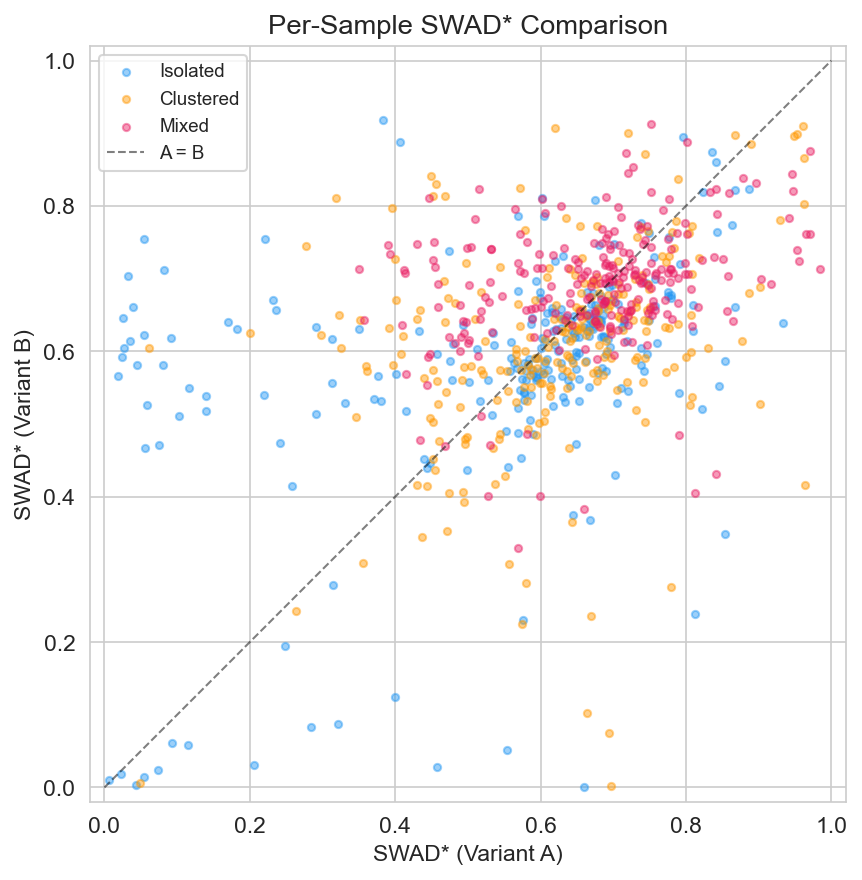

In [37]:
# ============================================================
# FIGURE B11: Scatter -- SWAD*(A) vs SWAD*(B) colored by scene type
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 6))
for st in SCENE_ORDER:
    sub = df_paired[df_paired.scene_type == st]
    ax.scatter(sub['swad_star_a'], sub['swad_star_b'], s=12, alpha=0.45,
               color=SCENE_COLORS[st], label=st)

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='A = B')
ax.set_xlabel('SWAD* (Variant A)')
ax.set_ylabel('SWAD* (Variant B)')
ax.set_title('Per-Sample SWAD* Comparison')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.set_aspect('equal')
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_swad_scatter_a_vs_b.pdf'))
plt.show()

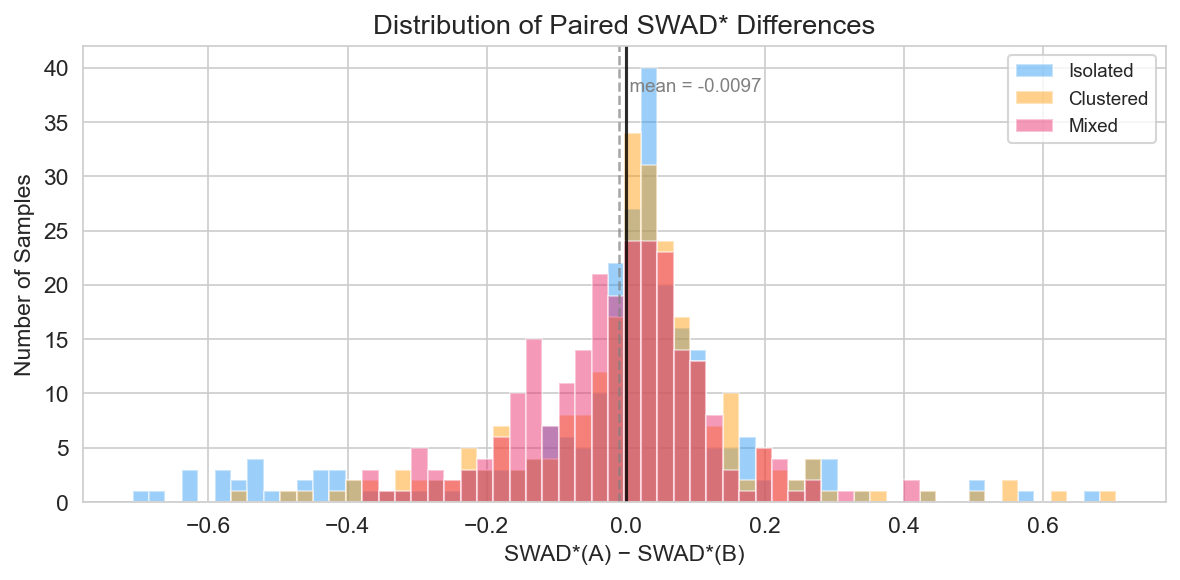

In [38]:
# ============================================================
# FIGURE B12: Histogram -- SWAD*(A) - SWAD*(B) distribution
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4))

diff_vals = -df_paired['swad_delta']  # A - B

bins = np.linspace(diff_vals.min() - 0.01, diff_vals.max() + 0.01, 61)
for st in SCENE_ORDER:
    sub = -df_paired[df_paired.scene_type == st]['swad_delta']
    ax.hist(sub, bins=bins, alpha=0.45, label=st,
            color=SCENE_COLORS[st], edgecolor='white')

ax.axvline(0, color='black', ls='-', lw=1.5, alpha=0.8)
ax.set_xlabel('SWAD*(A) \u2212 SWAD*(B)')
ax.set_ylabel('Number of Samples')
ax.set_title('Distribution of Paired SWAD* Differences')
ax.legend(fontsize=9)

ax.axvline(diff_vals.mean(), color='grey', ls='--', lw=1.2, alpha=0.7)
ax.text(diff_vals.mean(), ax.get_ylim()[1] * 0.9,
        f'  mean = {diff_vals.mean():+.4f}', fontsize=9, color='grey')

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_swad_diff_histogram.pdf'))
plt.show()

In [39]:
# ============================================================
# Table: Win/Loss/Tie with Wilcoxon p-values (for LaTeX)
# ============================================================

print('\n=== WIN/LOSS/TIE TABLE (for LaTeX) ===')
print(f'{"Scene Type":<12} {"N":>4} {"A Wins":>7} {"B Wins":>7} {"Tie":>5} '
      f'{"Mean \u0394":>8} {"p-value":>10}')
print('-' * 60)

for st in SCENE_ORDER + ['Overall']:
    sub = df_paired[df_paired.scene_type == st] if st != 'Overall' else df_paired
    n = len(sub)
    aw = (sub.winner == 'A').sum()
    bw = (sub.winner == 'B').sum()
    ti = (sub.winner == 'Tie').sum()
    md = sub['swad_delta'].mean()
    nz = sub['swad_delta'].values
    nz = nz[nz != 0]
    if len(nz) >= 10:
        _, p = stats.wilcoxon(nz, alternative='two-sided')
        p_str = f'{p:.2e}'
    else:
        p_str = '--'
    print(f'{st:<12} {n:>4} {aw:>7} {bw:>7} {ti:>5} {md:>+8.4f} {p_str:>10}')


=== WIN/LOSS/TIE TABLE (for LaTeX) ===
Scene Type      N  A Wins  B Wins   Tie   Mean Δ    p-value
------------------------------------------------------------
Isolated      250     138      91    21  +0.0262   2.93e-01
Clustered     250     144      87    19  -0.0125   1.09e-02
Mixed         250     113     116    21  +0.0154   1.43e-01
Overall       750     395     294    61  +0.0097   2.19e-01


## Computational Cost Comparison

In [40]:
# ============================================================
# Computational cost: wall time, evaluations, early stop rate
# ============================================================

print('=== Computational Cost Comparison ===')
print(f'{"Metric":<25} {"Variant A":>12} {"Variant B":>12} {"Ratio B/A":>10}')
print('-' * 62)

ea = df_paired['total_evaluations_a'].mean()
eb = df_paired['total_evaluations_b'].mean()
print(f'{"Mean evaluations":<25} {ea:>12.1f} {eb:>12.1f} {eb/ea:>10.2f}')

es_a = df_paired['early_stopped_a'].mean()
es_b = df_paired['early_stopped_b'].mean()
print(f'{"Early-stop rate":<25} {100*es_a:>11.1f}% {100*es_b:>11.1f}% {es_b/es_a if es_a > 0 else float("inf"):>10.2f}')

ns_a = df_paired['n_solutions_a'].mean()
ns_b = df_paired['n_solutions_b'].mean()
print(f'{"Mean front size":<25} {ns_a:>12.1f} {ns_b:>12.1f} {ns_b/ns_a:>10.2f}')

=== Computational Cost Comparison ===
Metric                       Variant A    Variant B  Ratio B/A
--------------------------------------------------------------
Mean evaluations                 183.4        277.2       1.51
Early-stop rate                  73.1%        50.1%       0.69
Mean front size                   17.8         18.5       1.04


## Budget Concentration Revisited

In [41]:
# ============================================================
# Budget patterns in B-win vs A-win samples
# ============================================================

df_paired_ext = df_paired.merge(
    df_b[['scene_type', 'sample_id', 'swad_hhi_img', 'swad_hhi_txt',
           'swad_eff_img', 'swad_eff_txt', 'swad_maxshare_img', 'swad_maxshare_txt',
           'swad_img_budget_used', 'swad_txt_budget_used']],
    on=['scene_type', 'sample_id'],
    how='left'
)

print('=== Budget Concentration by Winner ===')
print(f'{"Winner":<12} {"N":>5} '
      f'{"Eff Img":>8} {"Eff Txt":>8} '
      f'{"MaxSh Img":>10} {"MaxSh Txt":>10} '
      f'{"Img Budget":>11} {"Txt Budget":>11}')
print('-' * 80)

for w in ['A', 'B', 'Tie']:
    sub = df_paired_ext[df_paired_ext.winner == w]
    if len(sub) == 0:
        continue
    print(f'{w + " wins":<12} {len(sub):>5} '
          f'{sub.swad_eff_img.mean():>8.2f} '
          f'{sub.swad_eff_txt.mean():>8.2f} '
          f'{sub.swad_maxshare_img.mean():>9.1%} '
          f'{sub.swad_maxshare_txt.mean():>9.1%} '
          f'{sub.swad_img_budget_used.mean():>11.4f} '
          f'{sub.swad_txt_budget_used.mean():>11.4f}')


=== Budget Concentration by Winner ===
Winner           N  Eff Img  Eff Txt  MaxSh Img  MaxSh Txt  Img Budget  Txt Budget
--------------------------------------------------------------------------------
A wins         395     3.21     2.99     47.7%     48.9%      0.4112      0.5255
B wins         294     3.11     3.01     49.0%     48.7%      0.3944      0.5531
Tie wins        61     3.10     3.02     48.7%     48.2%      0.4271      0.5899


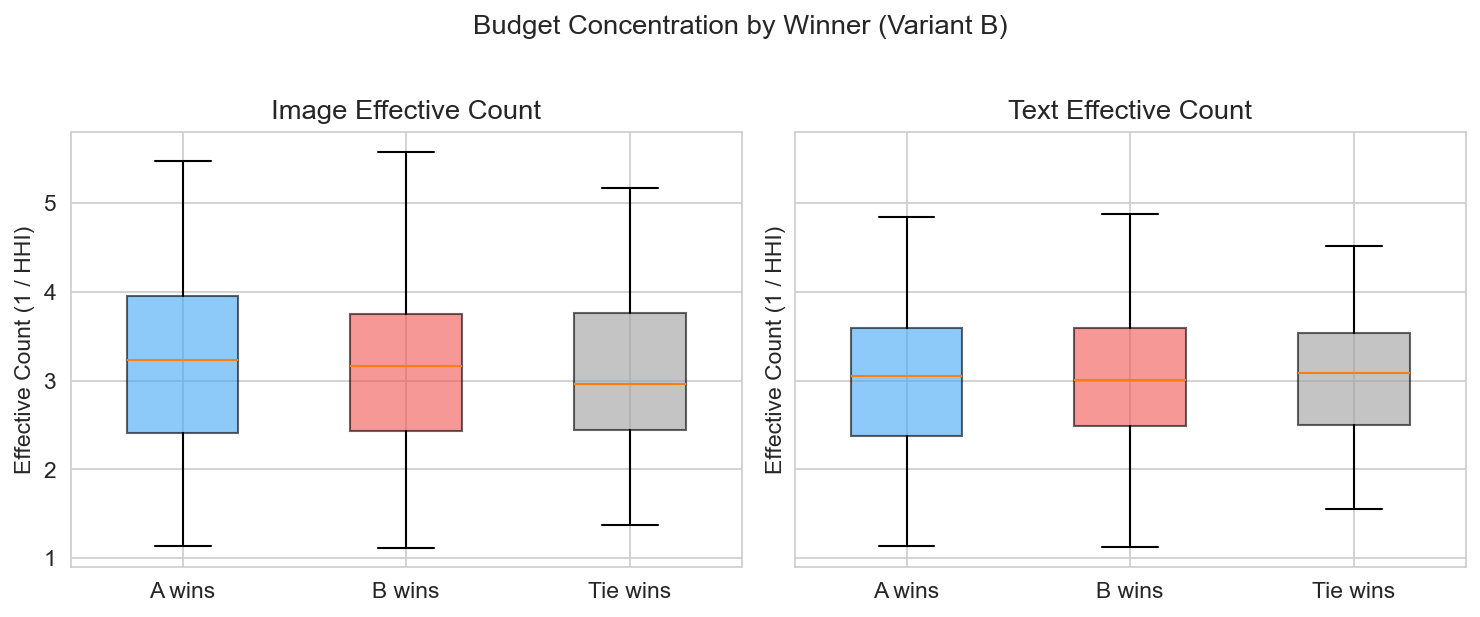

In [42]:
# ============================================================
# FIGURE B13: Budget concentration -- B-wins vs A-wins
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

colors_w = {'A wins': '#42A5F5', 'B wins': '#EF5350', 'Tie wins': '#9E9E9E'}

for ax, col, title in [(axes[0], 'swad_eff_img', 'Image Effective Count'),
                        (axes[1], 'swad_eff_txt', 'Text Effective Count')]:
    winner_groups = {}
    for w in ['A', 'B', 'Tie']:
        sub = df_paired_ext[df_paired_ext.winner == w][col].dropna()
        if len(sub) > 0:
            winner_groups[f'{w} wins'] = sub.values

    labels = list(winner_groups.keys())
    data = list(winner_groups.values())

    bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)
    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(colors_w.get(label, '#9E9E9E'))
        patch.set_alpha(0.6)
    ax.set_title(title)
    ax.set_ylabel('Effective Count (1 / HHI)')

fig.suptitle('Budget Concentration by Winner (Variant B)', y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'fig_b_budget_by_winner.pdf'))
plt.show()


## Summary Statistics

In [43]:
print('=' * 80)
print('VARIANT B -- KEY NUMBERS FOR EVALUATION CHAPTER')
print('=' * 80)

s = df_b
print(f'\n--- Sample counts ---')
print(f'Total samples: {len(s)}')
print(f'Total Pareto solutions: {len(df_b_sols):,}')
print(f'Mean front size: {s.n_solutions.mean():.1f} (std={s.n_solutions.std():.1f})')

print(f'\n--- Detection Degradation (SWAD*) ---')
print(f'Mean IoU_M: {s.swad_iou_m.mean():.4f} (std={s.swad_iou_m.std():.4f})')
print(f'Median IoU_M: {s.swad_iou_m.median():.4f}')
print(f'Mean \u03b4_M+: {s.swad_delta_m.mean():.4f}')
print(f'IoU_M = 0: {(s.swad_iou_m == 0).sum()}')
print(f'IoU_M < 0.1: {(s.swad_iou_m < 0.1).sum()}')
print(f'IoU_M \u2264 0.35: {(s.swad_iou_m <= 0.35).sum()}')

print(f'\n--- Stealth ---')
print(f'Mean d_I: {s.swad_img_dist.mean():.4f}')
print(f'Mean d_T: {s.swad_txt_dist.mean():.4f}')
print(f'Mean \u03a6: {s.swad_phi.mean():.4f}')
print(f'\u03a6 > 0.8: {(s.swad_phi > 0.8).sum()} ({100*(s.swad_phi > 0.8).mean():.1f}%)')
print(f'\u03a6 > 0.9: {(s.swad_phi > 0.9).sum()} ({100*(s.swad_phi > 0.9).mean():.1f}%)')

print(f'\n--- SWAD* ---')
print(f'Mean: {s.swad_star.mean():.4f}')
print(f'Median: {s.swad_star.median():.4f}')
print(f'Std: {s.swad_star.std():.4f}')

print(f'\n--- Budget Utilization ---')
print(f'Mean image budget: {s.swad_img_budget_used.mean():.4f} / {BUDGET_MAX}')
print(f'Mean text budget: {s.swad_txt_budget_used.mean():.4f} / {BUDGET_MAX}')

print(f'Mean effective count (img): {s.swad_eff_img.mean():.2f}')
print(f'Mean effective count (txt): {s.swad_eff_txt.mean():.2f}')
print(f'Mean HHI (img): {s.swad_hhi_img.mean():.3f}')
print(f'Mean HHI (txt): {s.swad_hhi_txt.mean():.3f}')
print(f'Mean max share (img): {s.swad_maxshare_img.mean():.1%}')
print(f'Mean max share (txt): {s.swad_maxshare_txt.mean():.1%}')
print(f'\n--- Early Stopping ---')
print(f'Rate: {s.early_stopped.mean():.1%}')
es = s[s.early_stopped]
if len(es) > 0:
    print(f'Mean gen: {es.early_stop_gen.mean():.1f}')
    print(f'Mean evals: {s.total_evaluations.mean():.0f}')

print(f'\n--- L2 vs SWAD* Agreement ---')
print(f'Agreement rate: {s.l2_swad_agree.mean():.1%}')

VARIANT B -- KEY NUMBERS FOR EVALUATION CHAPTER

--- Sample counts ---
Total samples: 750
Total Pareto solutions: 13,911
Mean front size: 18.5 (std=8.6)

--- Detection Degradation (SWAD*) ---
Mean IoU_M: 0.0615 (std=0.1615)
Median IoU_M: 0.0000
Mean δ_M+: 0.9278
IoU_M = 0: 509
IoU_M < 0.1: 634
IoU_M ≤ 0.35: 717

--- Stealth ---
Mean d_I: 0.0973
Mean d_T: 0.2468
Mean Φ: 0.6794
Φ > 0.8: 92 (12.3%)
Φ > 0.9: 24 (3.2%)

--- SWAD* ---
Mean: 0.6248
Median: 0.6432
Std: 0.1421

--- Budget Utilization ---
Mean image budget: 0.4059 / 1.0
Mean text budget: 0.5416 / 1.0
Mean effective count (img): 3.16
Mean effective count (txt): 3.00
Mean HHI (img): 0.355
Mean HHI (txt): 0.361
Mean max share (img): 48.3%
Mean max share (txt): 48.8%

--- Early Stopping ---
Rate: 50.1%
Mean gen: 3.8
Mean evals: 277

--- L2 vs SWAD* Agreement ---
Agreement rate: 88.8%


In [44]:
print('\n=== PER-SCENE-TYPE SUMMARY TABLE (for LaTeX) ===\n')

for st in SCENE_ORDER + ['Overall']:
    sub = s[s.scene_type == st] if st != 'Overall' else s
    print(f'--- {st} (N={len(sub)}) ---')
    print(f'  Baseline IoU: {sub.baseline_iou.mean():.3f} \u00b1 {sub.baseline_iou.std():.3f}')
    print(f'  SWAD* IoU_M:  {sub.swad_iou_m.mean():.3f} \u00b1 {sub.swad_iou_m.std():.3f}')
    print(f'  SWAD*:        {sub.swad_star.mean():.4f} \u00b1 {sub.swad_star.std():.4f}')
    print(f'  d_I:          {sub.swad_img_dist.mean():.4f} \u00b1 {sub.swad_img_dist.std():.4f}')
    print(f'  d_T:          {sub.swad_txt_dist.mean():.4f} \u00b1 {sub.swad_txt_dist.std():.4f}')
    print(f'  \u03a6:            {sub.swad_phi.mean():.4f} \u00b1 {sub.swad_phi.std():.4f}')
    print(f'  \u03b4_M+:         {sub.swad_delta_m.mean():.4f} \u00b1 {sub.swad_delta_m.std():.4f}')
    print(f'  IoU=0:        {(sub.swad_iou_m == 0).sum()} ({100*(sub.swad_iou_m == 0).mean():.1f}%)')
    print(f'  IoU<0.1:      {(sub.swad_iou_m < 0.1).sum()} ({100*(sub.swad_iou_m < 0.1).mean():.1f}%)')
    print(f'  IoU\u22640.35:     {(sub.swad_iou_m <= 0.35).sum()} ({100*(sub.swad_iou_m <= 0.35).mean():.1f}%)')
    print(f'  Img budget:   {sub.swad_img_budget_used.mean():.4f}')
    print(f'  Txt budget:   {sub.swad_txt_budget_used.mean():.4f}')
    print(f'  Eff count img: {sub.swad_eff_img.mean():.2f}')
    print(f'  Eff count txt: {sub.swad_eff_txt.mean():.2f}')
    print(f'  Max share img: {sub.swad_maxshare_img.mean():.1%}')
    print(f'  Max share txt: {sub.swad_maxshare_txt.mean():.1%}')
    print(f'  ES rate:      {sub.early_stopped.mean():.1%}')
    print()


=== PER-SCENE-TYPE SUMMARY TABLE (for LaTeX) ===

--- Isolated (N=250) ---
  Baseline IoU: 0.923 ± 0.077
  SWAD* IoU_M:  0.097 ± 0.222
  SWAD*:        0.5763 ± 0.1644
  d_I:          0.0970 ± 0.0292
  d_T:          0.2716 ± 0.1187
  Φ:            0.6570 ± 0.1043
  δ_M+:         0.8948 ± 0.2391
  IoU=0:        145 (58.0%)
  IoU<0.1:      203 (81.2%)
  IoU≤0.35:     228 (91.2%)
  Img budget:   0.3888
  Txt budget:   0.5301
  Eff count img: 3.04
  Eff count txt: 2.93
  Max share img: 49.3%
  Max share txt: 49.8%
  ES rate:      30.8%

--- Clustered (N=250) ---
  Baseline IoU: 0.841 ± 0.126
  SWAD* IoU_M:  0.073 ± 0.149
  SWAD*:        0.6081 ± 0.1404
  d_I:          0.0952 ± 0.0241
  d_T:          0.2518 ± 0.1241
  Φ:            0.6766 ± 0.1108
  δ_M+:         0.9095 ± 0.1823
  IoU=0:        136 (54.4%)
  IoU<0.1:      195 (78.0%)
  IoU≤0.35:     239 (95.6%)
  Img budget:   0.4239
  Txt budget:   0.5386
  Eff count img: 3.10
  Eff count txt: 2.96
  Max share img: 49.8%
  Max share txt: 5

In [45]:
# ============================================================
# COMPARISON SUMMARY
# ============================================================

print('=' * 80)
print('VARIANT A vs B -- COMPARISON SUMMARY FOR EVALUATION CHAPTER')
print('=' * 80)

p = df_paired

print(f'\n--- Overall ---')
print(f'Mean SWAD*:   A={p.swad_star_a.mean():.4f}, B={p.swad_star_b.mean():.4f}, '
      f'\u0394={p.swad_delta.mean():+.4f}')
print(f'Median SWAD*: A={p.swad_star_a.median():.4f}, B={p.swad_star_b.median():.4f}')

print(f'\n--- Win/Loss/Tie ---')
print(f'A wins: {(p.winner=="A").sum()} ({100*(p.winner=="A").mean():.1f}%)')
print(f'B wins: {(p.winner=="B").sum()} ({100*(p.winner=="B").mean():.1f}%)')
print(f'Ties:   {(p.winner=="Tie").sum()} ({100*(p.winner=="Tie").mean():.1f}%)')

print(f'\n--- Detection Degradation ---')
print(f'Mean IoU_M:   A={p.swad_iou_m_a.mean():.4f}, B={p.swad_iou_m_b.mean():.4f}')
print(f'Mean \u03b4_M+:    A={p.swad_delta_m_a.mean():.4f}, B={p.swad_delta_m_b.mean():.4f}')

print(f'\n--- Stealth ---')
print(f'Mean d_I:     A={p.swad_img_dist_a.mean():.4f}, B={p.swad_img_dist_b.mean():.4f}')
print(f'Mean d_T:     A={p.swad_txt_dist_a.mean():.4f}, B={p.swad_txt_dist_b.mean():.4f}')
print(f'Mean \u03a6:      A={p.swad_phi_a.mean():.4f}, B={p.swad_phi_b.mean():.4f}')

print(f'\n--- Computational Cost ---')
print(f'Mean evals:   A={p.total_evaluations_a.mean():.0f}, B={p.total_evaluations_b.mean():.0f}')
print(f'ES rate:      A={p.early_stopped_a.mean():.1%}, B={p.early_stopped_b.mean():.1%}')
print(f'Mean front:   A={p.n_solutions_a.mean():.1f}, B={p.n_solutions_b.mean():.1f}')

VARIANT A vs B -- COMPARISON SUMMARY FOR EVALUATION CHAPTER

--- Overall ---
Mean SWAD*:   A=0.6151, B=0.6248, Δ=+0.0097
Median SWAD*: A=0.6492, B=0.6432

--- Win/Loss/Tie ---
A wins: 395 (52.7%)
B wins: 294 (39.2%)
Ties:   61 (8.1%)

--- Detection Degradation ---
Mean IoU_M:   A=0.1295, B=0.0615
Mean δ_M+:    A=0.8483, B=0.9278

--- Stealth ---
Mean d_I:     A=0.0666, B=0.0973
Mean d_T:     A=0.2051, B=0.2468
Mean Φ:      A=0.7407, B=0.6794

--- Computational Cost ---
Mean evals:   A=183, B=277
ES rate:      A=73.1%, B=50.1%
Mean front:   A=17.8, B=18.5
